# 15. Modelo de Previsión de Demanda CRUZBER
## Construcción desde Datos Internos — Estrategia Nacional + Canal × Región
**Proyecto:** CRUZBER | ISDI MDA-13 | Forecasting B2B Ciclismo

## Contexto y Motivación

**¿Qué es CRUZBER?**
CRUZBER es un distribuidor mayorista B2B de equipamiento de ciclismo que opera en España y varios países europeos. Su negocio consiste en suministrar piezas, componentes y accesorios a tiendas de bicicletas, flotas corporativas y grandes cadenas deportivas. A diferencia del retail directo al consumidor, la demanda B2B es irregular, concentrada en pocos clientes clave y muy sensible a la estacionalidad deportiva.

**¿Por qué es crítica la previsión de demanda?**

Una previsión precisa permite a CRUZBER:
- **Optimizar el stock**: evitar roturas de inventario en temporada alta y excesos en temporada baja
- **Planificar la producción y compras** con suficiente antelación
- **Mejorar el servicio al cliente**: tener el producto disponible cuando el canal lo necesita
- **Reducir costes financieros**: el stock inmovilizado tiene un coste de capital significativo

**¿Por qué construimos desde los datos internos brutos?**

Iteraciones anteriores del proyecto utilizaban ficheros intermedios ya procesados (`df_final_modelado.csv`), lo que dificultaba la trazabilidad y ocultaba decisiones de filtrado. En este notebook partimos directamente de `LineasAlbaranCliente.xlsx` — el fichero transaccional original — para garantizar reproducibilidad total y máximo control sobre los datos.

**¿Qué producirá este notebook?**

Se construirán y evaluarán **tres modelos complementarios** con CatBoost (gradient boosting):
1. **Modelo A — Nacional**: predicción de demanda total por SKU a nivel España (todos los canales)
2. **Modelo B — Tradicional × Región**: predicción por SKU y región para el canal Tradicional
3. **Modelo C — FLEET Nacional**: predicción para el canal FLEET (contratos corporativos)

Cada modelo se evaluará con datos reales de 2024 (test) y se comparará contra la previsión interna de CRUZBER (`PrevisionVentasAA`).

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import re, warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')
RANDOM_STATE = 42
print('Librerias cargadas.')

Librerias cargadas.


## 1. Carga y Limpieza de Datos Transaccionales

`LineasAlbaranCliente.xlsx` contiene el registro bruto de cada línea de albarán emitida por CRUZBER: cada fila es una unidad de producto vendida a un cliente en una fecha concreta. Con casi un millón de registros, es la fuente de verdad del negocio.

Antes de cualquier análisis necesitamos limpiar este fichero: eliminar exportaciones, devoluciones y períodos fuera de alcance.

In [12]:
# Carga del fichero transaccional bruto
df_raw = pd.read_excel('../Datasets/Datos Internos/LineasAlbaranCliente.xlsx')
print(f'Dataset bruto: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas')
print(f'\nColumnas: {df_raw.columns.tolist()}')
print(f'\nMuestra SerieAlbaran: {df_raw["SerieAlbaran"].unique()[:20]}')
df_raw.head(3)

Dataset bruto: 938,230 filas x 20 columnas

Columnas: ['CodigoCliente', 'SerieAlbaran', 'NumeroAlbaran', 'FechaAlbaran', 'CodigoArticulo', 'CodigoAlmacen', 'Unidades', 'Precio', 'PrecioCoste', 'ImporteDescuento', 'ImporteCoste', 'ImporteBruto', 'ImporteNeto', 'ImporteProntoPago', 'BaseImponible', 'ImporteLiquido', '%Descuento', '%Descuento2', 'PorMargenBeneficio', 'MargenBeneficio']

Muestra SerieAlbaran: [21 19 20 24 22 23 'A23' 'INC24' 'DV24' 'DV23' 'INC23' 'INC22' 'DV22' 'V4'
 'A24' 'A22' 'A21' 'A20' 'A19' 'DV19']


,CodigoCliente,SerieAlbaran,NumeroAlbaran,FechaAlbaran,CodigoArticulo,CodigoAlmacen,Unidades,Precio,PrecioCoste,ImporteDescuento,ImporteCoste,ImporteBruto,ImporteNeto,ImporteProntoPago,BaseImponible,ImporteLiquido,%Descuento,%Descuento2,PorMargenBeneficio,MargenBeneficio
0,18530,21,29242,"viernes, 30 de julio de 2021",940-540,0,3.0,170.0,120.000000,0.0,360.000000,510.0,510.0,10.20,499.80,499.80,0.0,0.0,27.971188,139.800000
1,18530,21,29242,"viernes, 30 de julio de 2021",940-006,0,357.0,18.5,14.086994,0.0,5029.056931,6604.5,6604.5,132.09,6472.41,6472.41,0.0,0.0,22.300087,1443.353069
2,18530,21,29242,"viernes, 30 de julio de 2021",940-007,0,204.0,18.0,13.650033,0.0,2784.606832,3672.0,3672.0,73.44,3598.56,3598.56,0.0,0.0,22.618858,813.953168


### 1.1 Filtros de Calidad: ¿Qué datos conservamos?

Aplicamos tres filtros secuenciales:

1. **Filtro Nacional** (`SerieAlbaran` numérico): Las series con letras corresponden a exportaciones. Nos centramos exclusivamente en el mercado español, donde la lógica comercial y estacional es homogénea.

2. **Eliminación de Devoluciones** (`Unidades <= 0`): Las líneas con unidades negativas o cero representan devoluciones de mercancía. No reflejan demanda real.

3. **Ventana temporal 2022-2024**: Tres años de historial ofrecen suficiente señal para capturar estacionalidad anual y tendencias de crecimiento.

In [13]:
MONTH_MAP = {
    'enero':1,'febrero':2,'marzo':3,'abril':4,'mayo':5,'junio':6,
    'julio':7,'agosto':8,'septiembre':9,'octubre':10,'noviembre':11,'diciembre':12
}

def parse_spanish_date(date_str):
    """Parsea fechas en formato espanol: 'viernes, 30 de julio de 2021'"""
    if pd.isna(date_str): return pd.NaT
    s = str(date_str).lower().strip()
    m = re.search(r'(\d{1,2})\s+de\s+(\w+)\s+de\s+(\d{4})', s)
    if m:
        day, month_name, year = m.groups()
        month = MONTH_MAP.get(month_name)
        if month:
            return pd.Timestamp(int(year), month, int(day))
    return pd.NaT

# 1. Filtro nacional
df_nac = df_raw[df_raw['SerieAlbaran'].astype(str).str.match(r'^\d+')].copy()
n_nacional = len(df_nac)

# 2. Parsear fechas
print('Parseando fechas en formato espanol...')
df_nac['fecha'] = df_nac['FechaAlbaran'].apply(parse_spanish_date)
df_nac = df_nac.dropna(subset=['fecha'])

# 3. Extraer anio e ISO week
df_nac['anio'] = df_nac['fecha'].dt.isocalendar().year.astype(int)
df_nac['semana_anio'] = df_nac['fecha'].dt.isocalendar().week.astype(int)

# 4. Filtro 2022-2024
df_nac = df_nac[df_nac['anio'].between(2022, 2024)].copy()
n_periodo = len(df_nac)

# 5. Eliminar devoluciones
df_nac = df_nac[df_nac['Unidades'] > 0].copy()
n_limpio = len(df_nac)

print(f'\n=== Resumen de filtros ===')
print(f'Total filas brutas              : {len(df_raw):>10,}')
print(f'Tras filtro nacional            : {n_nacional:>10,}')
print(f'Tras filtro 2022-2024           : {n_periodo:>10,}')
print(f'Devoluciones eliminadas (<=0)   : {n_periodo - n_limpio:>10,}')
print(f'Dataset limpio                  : {n_limpio:>10,}')
print(f'\nRango de fechas: {df_nac["fecha"].min().date()} => {df_nac["fecha"].max().date()}')

Parseando fechas en formato espanol...

=== Resumen de filtros ===
Total filas brutas              :    938,230
Tras filtro nacional            :    893,280
Tras filtro 2022-2024           :    459,423
Devoluciones eliminadas (<=0)   :     10,096
Dataset limpio                  :    449,327

Rango de fechas: 2022-01-03 => 2024-09-26


## 2. Enriquecimiento con Datos Maestros

El fichero transaccional sólo contiene códigos de cliente y artículo. Para construir modelos útiles necesitamos añadir información de negocio mediante joins:

| Tabla Maestra | Información que añade | Clave de join |
|---|---|---|
| `MaestroClientes` | Provincia, autonomía, tipo comercial | `CodigoCliente` |
| `Agrupacion Canales venta` | Canal de venta (Tradicional/FLEET/Nueva Distribución) | `TipoCruz` |
| `MaestroArticulos` | Clasificación ABC, previsión interna, tarifa | `CodigoArticulo` |
| `Familias Articulos` | Gama de producto (PC/CV/ACC/OEM) | `AgrupacionListado` |

### 2.1 Canal de Venta y Provincia del Cliente

Cada cliente tiene asignado un `TipoCruz` que se mapea al canal de venta. Los canales nacionales son: **Tradicional** (tiendas de bicicletas independientes), **FLEET** (flotas corporativas), **Nueva Distribución** (cadenas deportivas y online) y **Primeros Equipos** (equipos ciclistas profesionales, que fusionamos en Tradicional por su volumen marginal).

La región geográfica se obtiene mapeando `CodigoAutonomia` (numérico) a 6 regiones comerciales: Noreste, Norte, Centro, Sur, Noroeste y Canarias. Usamos código numérico para evitar problemas de encoding con nombres en castellano.

In [14]:
# --- Maestro de clientes ---
df_clientes = pd.read_excel(
    '../Datasets/Datos Internos/MaestroClientes.xlsx',
    usecols=['CodigoCliente','Municipio','Provincia','Zona',
             'TipoCruz','CodigoProvincia','CodigoAutonomia','BajaEmpresaLc']
)
# Deduplicar por CodigoCliente (quedarse con el primer registro si hay duplicados)
df_clientes = df_clientes.drop_duplicates(subset='CodigoCliente', keep='first')

# --- Mapeo de canales ---
# Leemos las 3 primeras columnas por posicion (Canal, Agrupacion Canal, Tipo Agrupacion)
# Evita cualquier problema de encoding o nombres duplicados por columnas adicionales del Excel
df_canales = pd.read_excel(
    '../Datasets/Datos Internos/Agrupacion Canales venta.xlsx',
    usecols=[0, 1, 2]
)
df_canales.columns = ['TipoCruz', 'agrupacion_canal', 'tipo_agrupacion']
df_canales = df_canales.drop_duplicates(subset='TipoCruz')
print('Canales cargados:', len(df_canales), 'tipos de canal')
print(df_canales[['TipoCruz','agrupacion_canal','tipo_agrupacion']].to_string(index=False))

# Join 1: transacciones -> clientes (reset_index para evitar indices duplicados)
df_enriched = df_nac.merge(
    df_clientes[['CodigoCliente','Provincia','CodigoProvincia','CodigoAutonomia','TipoCruz','BajaEmpresaLc']],
    on='CodigoCliente', how='left'
).reset_index(drop=True)

# Join 2: clientes -> canal (reset_index de nuevo)
df_enriched = df_enriched.merge(
    df_canales, on='TipoCruz', how='left'
).reset_index(drop=True)

# Solo canal Nacional
df_esp = df_enriched[df_enriched['tipo_agrupacion'] == 'Nacional'].copy().reset_index(drop=True)

# Fusionar Primeros Equipos en Tradicional
df_esp['agrupacion_canal'] = df_esp['agrupacion_canal'].replace('Primeros Equipos', 'Tradicional')

# Mapeo CodigoAutonomia -> Region (numerico, sin encoding issues)
autonomia_to_region = {
    59:'Noreste', 65:'Noreste', 67:'Noreste',
    53:'Norte',   75:'Norte',   62:'Norte',   63:'Norte',
    64:'Centro',  57:'Centro',  55:'Centro',  58:'Centro',
    61:'Sur',     70:'Sur',     54:'Sur',     66:'Sur',
    71:'Noroeste',52:'Noroeste',56:'Noroeste',
    60:'Canarias'
}
df_esp['region'] = df_esp['CodigoAutonomia'].map(autonomia_to_region).fillna('Desconocido')

print(f'Filas nacionales: {len(df_esp):,}')
print(f'Clientes unicos : {df_esp["CodigoCliente"].nunique():,}')
print()
print('Distribucion por Canal:')
print(df_esp['agrupacion_canal'].value_counts())
print()
print('Distribucion por Region:')
print(df_esp['region'].value_counts())


Canales cargados: 32 tipos de canal
   TipoCruz   agrupacion_canal tipo_agrupacion
      Cruz1        Tradicional        Nacional
      Cruz2        Tradicional        Nacional
     Cruz2P        Tradicional        Nacional
     Cruz2W        Tradicional        Nacional
      Cruz3        Tradicional        Nacional
     Cruz3S        Tradicional        Nacional
     Cruz3W        Tradicional        Nacional
      Cruz4        Tradicional        Nacional
      Cruz5        Tradicional        Nacional
  CruzFLEET              FLEET        Nacional
     CruzND Nueva Distribución        Nacional
    CruzSPO Nueva Distribución        Nacional
    CruzWEB Nueva Distribución        Nacional
  UsuarioRK Nueva Distribución        Nacional
  UsuarioCR Nueva Distribución        Nacional
    CruzCON   Primeros Equipos        Nacional
    CruzOEM   Primeros Equipos        Nacional
    CruzExA       Distribución          Export
    CruzExB       Distribución          Export
    CruzExC       Distri

### 2.2 Enriquecimiento de Artículos

El maestro de artículos aporta inteligencia comercial clave:

- **TipoABC**: clasifica cada SKU según su importancia estratégica — A (críticos, alta rotación), B (relevantes), C (larga cola)
- **PrevisionVentasAA**: previsión anual interna de CRUZBER. Dividida entre 52 semanas da el benchmark semanal para comparar con nuestros modelos
- **FactorCrecimiento**: multiplicador de tendencia previsto por el equipo comercial
- **CR_GamaProducto**: familia de producto (PC=piezas, CV=bicicletas, ACC=accesorios, OEM)

In [15]:
# --- Maestro de articulos ---
df_art = pd.read_excel(
    '../Datasets/Datos Internos/MaestroArticulos.xlsx',
    usecols=['CodigoArticulo','AgrupacionListado','TipoABC',
             'PrevisionVentasAA','FactorCrecimiento','AreaCompetenciaLc','TarifaNacional','Obsoleto']
)
df_art = df_art[df_art['Obsoleto'] != 'Si'].copy()  # Eliminar articulos obsoletos
df_art['CodigoArticulo']       = df_art['CodigoArticulo'].astype(str).str.strip()
df_art['PrevisionVentasAA']    = pd.to_numeric(df_art['PrevisionVentasAA'],  errors='coerce').fillna(0)
df_art['FactorCrecimiento']    = pd.to_numeric(df_art['FactorCrecimiento'],  errors='coerce').fillna(1.0)
df_art['TarifaNacional']       = pd.to_numeric(df_art['TarifaNacional'],     errors='coerce').fillna(0)
df_art['AreaCompetenciaLc']    = df_art['AreaCompetenciaLc'].fillna('Desconocido').astype(str)
df_art['AgrupacionListado']    = df_art['AgrupacionListado'].astype(str).str.strip()
df_art['prevision_semanal_aa'] = df_art['PrevisionVentasAA'] / 52

# --- Familias de articulos ---
df_fam = pd.read_excel(
    '../Datasets/Datos Internos/Familias Articulos.xlsx',
    usecols=['AgrupacionListado','CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']
)
df_fam['AgrupacionListado'] = df_fam['AgrupacionListado'].astype(str).str.strip()
for col in ['CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']:
    df_fam[col] = df_fam[col].fillna('Desconocido').astype(str)

# Combinar
df_sku = df_art.merge(df_fam, on='AgrupacionListado', how='left')
for col in ['CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']:
    df_sku[col] = df_sku[col].fillna('Desconocido')
df_sku = df_sku.drop_duplicates(subset='CodigoArticulo')

# Join al dataset principal
df_esp['CodigoArticulo'] = df_esp['CodigoArticulo'].astype(str).str.strip()
df_master = df_esp.merge(df_sku, on='CodigoArticulo', how='left')

df_master['TipoABC'] = df_master['TipoABC'].fillna('C').astype(str)
for col in ['CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion','AreaCompetenciaLc']:
    df_master[col] = df_master[col].fillna('Desconocido').astype(str)
for col in ['FactorCrecimiento','TarifaNacional','prevision_semanal_aa','PrevisionVentasAA']:
    df_master[col] = df_master[col].fillna(0)

# Renombrar para consistencia
df_master = df_master.rename(columns={
    'CodigoArticulo': 'codigo_articulo',
    'Unidades':       'unidades',
    'ImporteNeto':    'importe_neto',
    'TipoABC':        'tipo_abc',
    'Provincia':      'provincia'
})

print(f'Dataset maestro: {df_master.shape[0]:,} filas x {df_master.shape[1]} columnas')
print(f'Clientes unicos : {df_master["CodigoCliente"].nunique():,}')
print(f'SKUs unicos     : {df_master["codigo_articulo"].nunique():,}')
print(f'Periodo         : {df_master["fecha"].min().date()} => {df_master["fecha"].max().date()}')
print(f'Importe neto    : EUR {df_master["importe_neto"].sum():,.0f}')

Dataset maestro: 298,238 filas x 41 columnas
Clientes unicos : 1,887
SKUs unicos     : 2,665
Periodo         : 2022-01-03 => 2024-09-26
Importe neto    : EUR 20,197,044


## 3. Análisis Exploratorio de Datos (EDA)

Antes de modelar, necesitamos entender la estructura de la demanda: ¿Qué años tienen más volumen? ¿Qué canal domina? ¿Hay estacionalidad clara? ¿Qué productos concentran la mayor parte de la demanda?

El EDA guiará las decisiones de ingeniería de características y arquitectura de modelos.

### 3.1 Visión General: Evolución de Ventas 2022-2024

Analizamos la evolución anual de unidades e importe neto. Esperamos ver tendencia de crecimiento dado el auge del ciclismo post-pandemia y la expansión del canal FLEET.

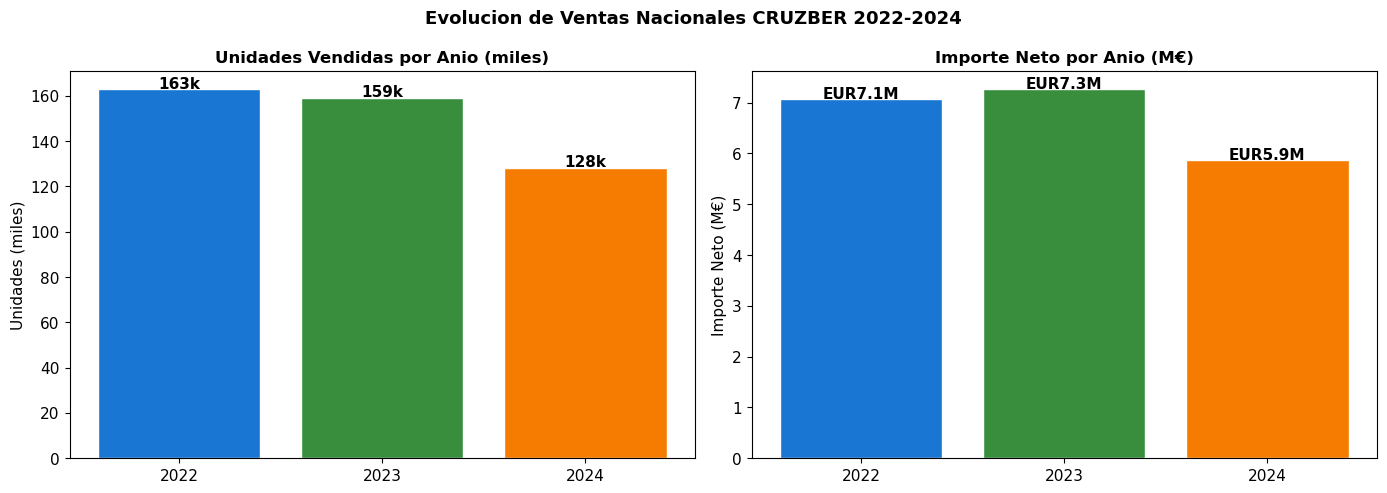


=== RESUMEN ANUAL ===
 anio  unidades importe_fmt  clientes  skus
 2022  162861.0    EUR7.07M       662  2036
 2023  159059.0    EUR7.26M      1054  2069
 2024  128126.0    EUR5.86M      1370  1971

Interpretacion: La evolucion anual muestra la tendencia real del negocio nacional. Crecimientos sostenidos indican expansion; caidas requieren analisis de causas.


In [16]:
# Resumen anual
annual = df_master.groupby('anio').agg(
    unidades    =('unidades','sum'),
    importe     =('importe_neto','sum'),
    clientes    =('CodigoCliente','nunique'),
    skus        =('codigo_articulo','nunique'),
    albaranes   =('NumeroAlbaran','nunique')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores = ['#1976D2','#388E3C','#F57C00']

axes[0].bar(annual['anio'].astype(str), annual['unidades']/1000,
            color=colores, edgecolor='white')
axes[0].set_title('Unidades Vendidas por Anio (miles)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Unidades (miles)')
for i, v in enumerate(annual['unidades']/1000):
    axes[0].text(i, v+0.5, f'{v:.0f}k', ha='center', fontweight='bold')

axes[1].bar(annual['anio'].astype(str), annual['importe']/1e6,
            color=colores, edgecolor='white')
axes[1].set_title('Importe Neto por Anio (M€)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Importe Neto (M€)')
for i, v in enumerate(annual['importe']/1e6):
    axes[1].text(i, v+0.02, f'EUR{v:.1f}M', ha='center', fontweight='bold')

plt.suptitle('Evolucion de Ventas Nacionales CRUZBER 2022-2024', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== RESUMEN ANUAL ===')
annual_d = annual.copy()
annual_d['importe_fmt'] = annual_d['importe'].apply(lambda x: f'EUR{x/1e6:.2f}M')
print(annual_d[['anio','unidades','importe_fmt','clientes','skus']].to_string(index=False))

print('\nInterpretacion: La evolucion anual muestra la tendencia real del negocio nacional. '
      'Crecimientos sostenidos indican expansion; caidas requieren analisis de causas.')

### 3.2 Análisis por Canal de Venta

CRUZBER opera con tres canales nacionales principales:
- **Tradicional**: tiendas de bicicletas independientes — canal histórico, pedidos frecuentes pero pequeños
- **Nueva Distribución**: cadenas deportivas y e-commerce — crecimiento acelerado
- **FLEET**: flotas corporativas — pocos clientes pero pedidos de gran volumen

Cada canal tiene patrones de demanda distintos, lo que justifica modelos diferenciados.

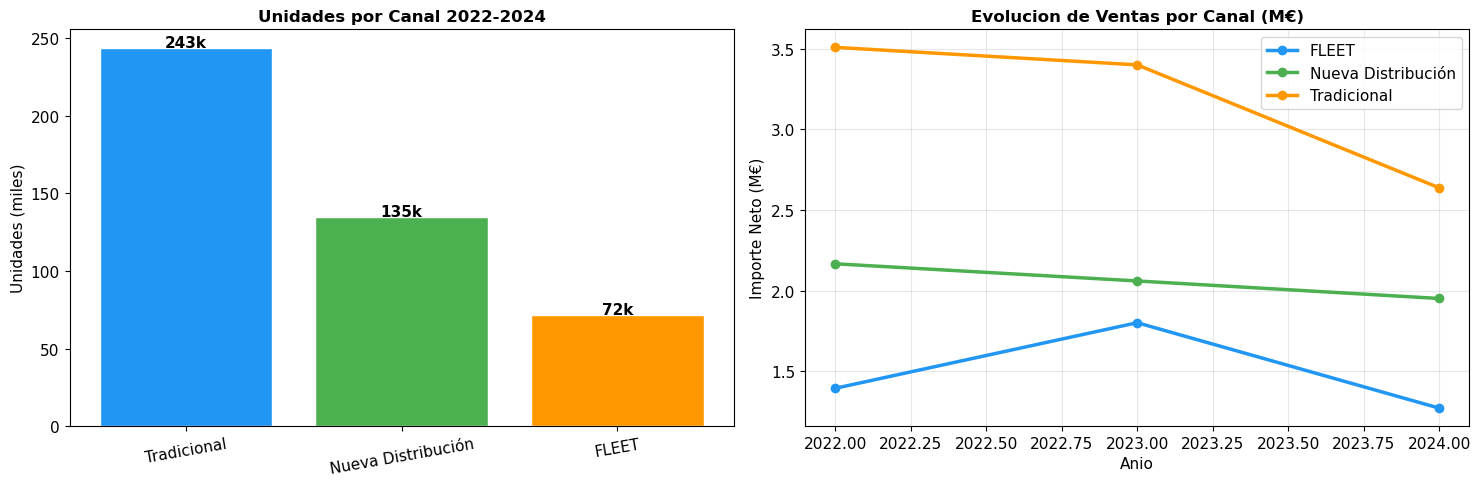


=== CUOTA POR CANAL ===
  agrupacion_canal  unidades  pct_und  pct_imp  clientes
       Tradicional  243421.0     54.1     47.3       449
Nueva Distribución  134892.0     30.0     30.6      1384
             FLEET   71733.0     15.9     22.1        54

Interpretacion: La distribucion por canal revela que la mayor parte del volumen en unidades proviene del canal Tradicional, mientras que FLEET puede aportar mayor valor economico por pedido.


In [17]:
canal_summary = df_master.groupby('agrupacion_canal').agg(
    unidades =('unidades','sum'),
    importe  =('importe_neto','sum'),
    clientes =('CodigoCliente','nunique'),
    skus     =('codigo_articulo','nunique')
).reset_index().sort_values('unidades', ascending=False)

canal_evol = df_master.groupby(['anio','agrupacion_canal'])['importe_neto'].sum().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colores_canal = ['#2196F3','#4CAF50','#FF9800','#9C27B0']

bars = axes[0].bar(canal_summary['agrupacion_canal'], canal_summary['unidades']/1000,
                   color=colores_canal[:len(canal_summary)], edgecolor='white')
axes[0].set_title('Unidades por Canal 2022-2024', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Unidades (miles)')
axes[0].tick_params(axis='x', rotation=10)
for bar, v in zip(bars, canal_summary['unidades']/1000):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.0f}k', ha='center', fontweight='bold')

for i, canal in enumerate(canal_evol.columns):
    axes[1].plot(canal_evol.index, canal_evol[canal]/1e6, marker='o',
                 linewidth=2.5, label=canal, color=colores_canal[i % len(colores_canal)])
axes[1].set_title('Evolucion de Ventas por Canal (M€)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Importe Neto (M€)')
axes[1].set_xlabel('Anio')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

canal_summary['pct_und'] = (canal_summary['unidades']/canal_summary['unidades'].sum()*100).round(1)
canal_summary['pct_imp'] = (canal_summary['importe']/canal_summary['importe'].sum()*100).round(1)
print('\n=== CUOTA POR CANAL ===')
print(canal_summary[['agrupacion_canal','unidades','pct_und','pct_imp','clientes']].to_string(index=False))
print('\nInterpretacion: La distribucion por canal revela que la mayor parte del volumen '
      'en unidades proviene del canal Tradicional, mientras que FLEET puede aportar '
      'mayor valor economico por pedido.')

### 3.3 Distribución Geográfica por Región

España se divide en 6 regiones comerciales para el análisis: Noreste (Cataluña, Valencia, Baleares), Norte (Aragón, País Vasco, Navarra, La Rioja), Centro (Madrid, Castillas, Extremadura), Sur (Andalucía, Murcia, Ceuta, Melilla), Noroeste (Galicia, Asturias, Cantabria) y Canarias.

La concentración geográfica guía la configuración regional del Modelo B.

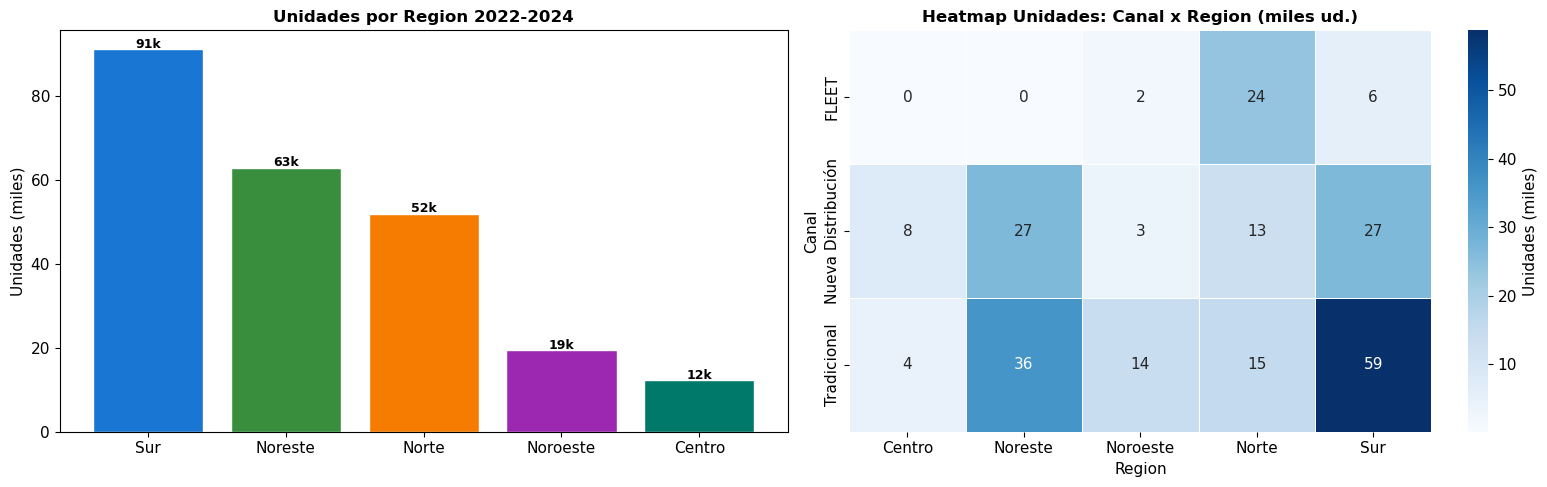


Interpretacion: Las regiones con mayor concentracion de demanda (Noreste, Centro) requieren mayor precision en el modelo regional. Las regiones pequeñas pueden tener historicos insuficientes y mayor incertidumbre en la prediccion.


In [18]:
region_summary = df_master[df_master['region'] != 'Desconocido'].groupby('region').agg(
    unidades =('unidades','sum'),
    importe  =('importe_neto','sum'),
    clientes =('CodigoCliente','nunique')
).reset_index().sort_values('unidades', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colores_reg = ['#1976D2','#388E3C','#F57C00','#9C27B0','#00796B','#C62828']

axes[0].bar(region_summary['region'], region_summary['unidades']/1000,
            color=colores_reg[:len(region_summary)], edgecolor='white')
axes[0].set_title('Unidades por Region 2022-2024', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Unidades (miles)')
for i, (_, row) in enumerate(region_summary.iterrows()):
    axes[0].text(i, row['unidades']/1000+0.3,
                 f"{row['unidades']/1000:.0f}k", ha='center', fontweight='bold', fontsize=9)

pivot = df_master[df_master['region']!='Desconocido'].groupby(
    ['agrupacion_canal','region'])['unidades'].sum().unstack(fill_value=0)
sns.heatmap(pivot/1000, annot=True, fmt='.0f', cmap='Blues', ax=axes[1],
            linewidths=0.5, cbar_kws={'label':'Unidades (miles)'})
axes[1].set_title('Heatmap Unidades: Canal x Region (miles ud.)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Canal')
plt.tight_layout()
plt.show()

print('\nInterpretacion: Las regiones con mayor concentracion de demanda (Noreste, Centro) '
      'requieren mayor precision en el modelo regional. Las regiones pequeñas pueden '
      'tener historicos insuficientes y mayor incertidumbre en la prediccion.')

### 3.4 Estacionalidad y Temporalidad

El ciclismo es un deporte marcadamente estacional: la demanda se concentra en primavera (semanas 15-25) con un segundo pico en verano (semanas 33-38). Navidad y el inicio del año registran una caída pronunciada.

Capturar correctamente este patrón es fundamental para el rendimiento del modelo. Lo haremos mediante features de seno/coseno y el indicador `temporada_alta`.

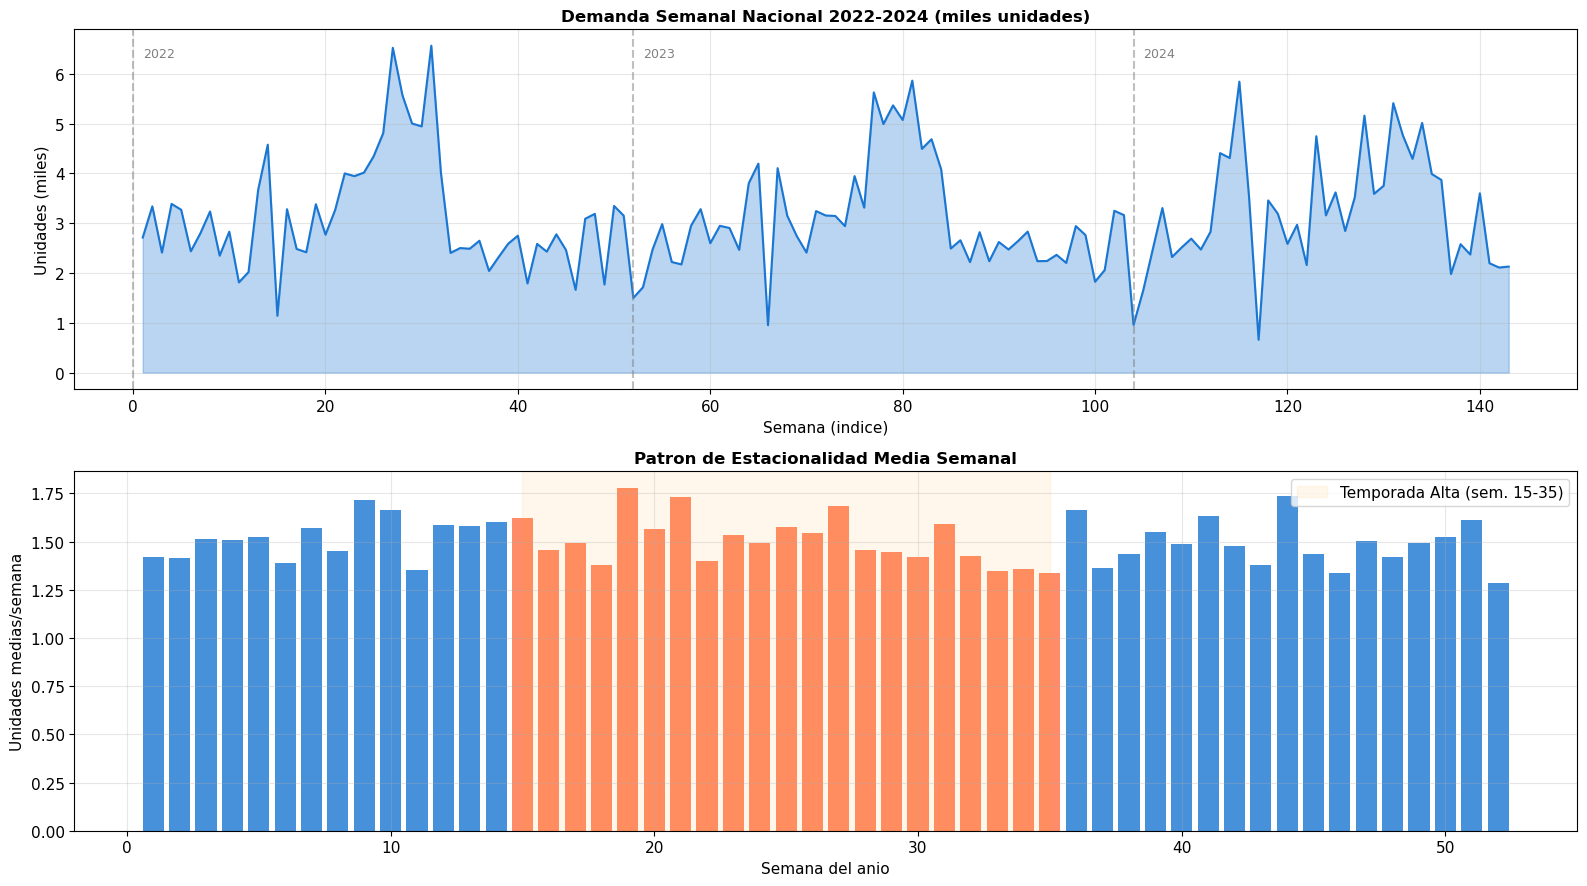

Semana pico de demanda: 19

Interpretacion: La estacionalidad es pronunciada y consistente entre anios. Los modelos deben capturar este patron para evitar errores sistematicos en la temporada alta.


In [19]:
weekly_total = df_master.groupby(['anio','semana_anio']).agg(
    unidades =('unidades','sum'),
    importe  =('importe_neto','sum')
).reset_index()
weekly_total['week_idx'] = (weekly_total['anio']-2022)*52 + weekly_total['semana_anio']

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# Serie temporal completa
axes[0].fill_between(weekly_total['week_idx'], weekly_total['unidades']/1000,
                      alpha=0.3, color='#1976D2')
axes[0].plot(weekly_total['week_idx'], weekly_total['unidades']/1000,
             color='#1976D2', linewidth=1.5)
for y_off, lbl in [(0,'2022'),(52,'2023'),(104,'2024')]:
    axes[0].axvline(x=y_off, color='gray', linestyle='--', alpha=0.5)
    axes[0].text(y_off+1, axes[0].get_ylim()[1]*0.92, lbl, fontsize=9, color='gray')
axes[0].set_title('Demanda Semanal Nacional 2022-2024 (miles unidades)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Unidades (miles)')
axes[0].set_xlabel('Semana (indice)')
axes[0].grid(alpha=0.3)

# Patron estacional medio
seasonal = df_master.groupby('semana_anio')['unidades'].mean().reset_index()
colors_s = ['#FF7043' if 15<=w<=35 else '#1976D2' for w in seasonal['semana_anio']]
axes[1].bar(seasonal['semana_anio'], seasonal['unidades'], color=colors_s, alpha=0.8)
axes[1].axvspan(15, 35, alpha=0.08, color='orange', label='Temporada Alta (sem. 15-35)')
axes[1].set_title('Patron de Estacionalidad Media Semanal', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Unidades medias/semana')
axes[1].set_xlabel('Semana del anio')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

pico_sem = seasonal.loc[seasonal['unidades'].idxmax(), 'semana_anio']
print(f'Semana pico de demanda: {pico_sem}')
print('\nInterpretacion: La estacionalidad es pronunciada y consistente entre anios. '
      'Los modelos deben capturar este patron para evitar errores sistematicos '
      'en la temporada alta.')

### 3.5 Concentración de Producto: Análisis ABC y Principio de Pareto

En distribución B2B es habitual que un número reducido de referencias concentre la mayor parte de la demanda (regla 80/20 de Pareto). Este análisis determina cuántos SKUs son realmente críticos y guía las decisiones sobre qué productos priorizar en la previsión.

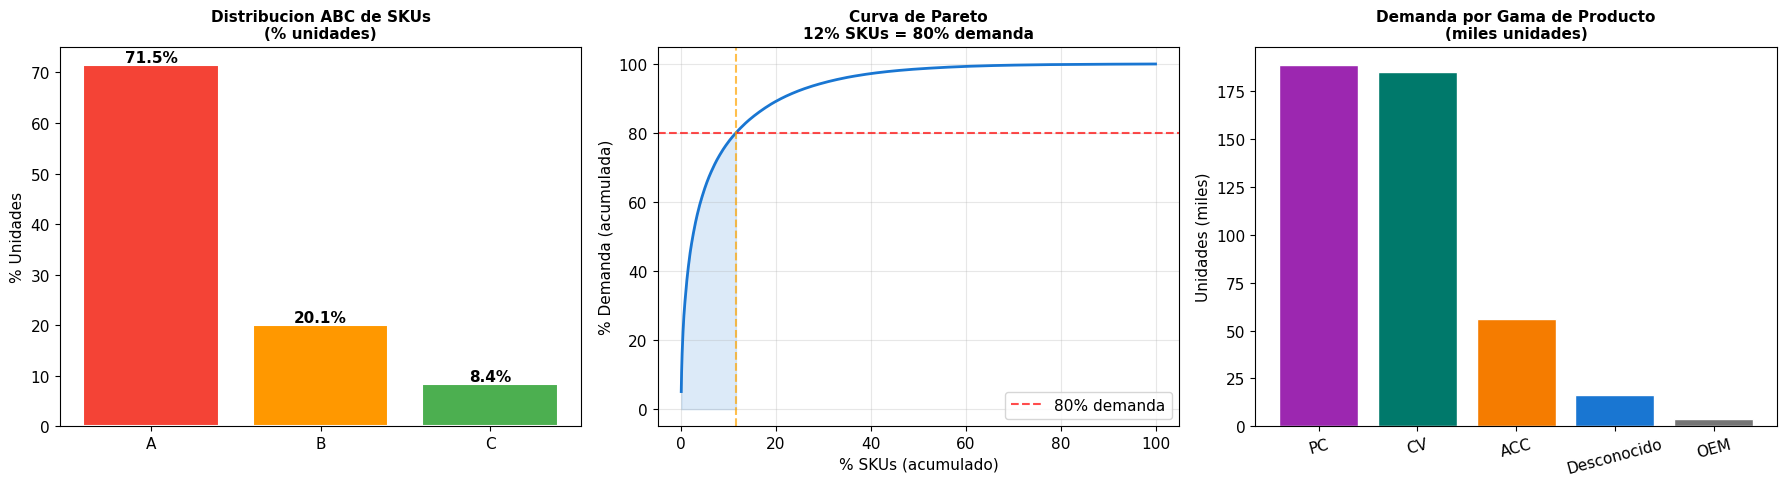

Concentracion: el 12% de los SKUs genera el 80% de la demanda

Interpretacion: El principio de Pareto se cumple en el catalogo de CRUZBER. Los SKUs tipo A son los mas criticos para la planificacion de stock.


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ABC
abc_data = df_master.groupby('tipo_abc')['unidades'].sum().sort_values(ascending=False)
abc_pct  = abc_data / abc_data.sum() * 100
axes[0].bar(abc_data.index, abc_pct.values,
            color=['#F44336','#FF9800','#4CAF50','#9E9E9E'][:len(abc_data)],
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribucion ABC de SKUs\n(% unidades)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('% Unidades')
for i, v in enumerate(abc_pct.values):
    axes[0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Pareto
sku_demand = df_master.groupby('codigo_articulo')['unidades'].sum().sort_values(ascending=False).reset_index()
sku_demand['cum_pct']  = sku_demand['unidades'].cumsum() / sku_demand['unidades'].sum() * 100
sku_demand['rank_pct'] = np.arange(1, len(sku_demand)+1) / len(sku_demand) * 100
axes[1].plot(sku_demand['rank_pct'], sku_demand['cum_pct'], color='#1976D2', linewidth=2)
axes[1].axhline(80, color='red', linestyle='--', alpha=0.7, label='80% demanda')
idx_80 = (sku_demand['cum_pct'] >= 80).idxmax()
pct_skus_80 = sku_demand.loc[idx_80, 'rank_pct']
axes[1].axvline(pct_skus_80, color='orange', linestyle='--', alpha=0.7)
axes[1].fill_between(sku_demand['rank_pct'][:idx_80+1], sku_demand['cum_pct'][:idx_80+1],
                      alpha=0.15, color='#1976D2')
axes[1].set_title(f'Curva de Pareto\n{pct_skus_80:.0f}% SKUs = 80% demanda',
                   fontsize=11, fontweight='bold')
axes[1].set_xlabel('% SKUs (acumulado)')
axes[1].set_ylabel('% Demanda (acumulada)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Gama producto
gama_data = df_master.groupby('CR_GamaProducto')['unidades'].sum().sort_values(ascending=False)
cols_gama = ['#9C27B0','#00796B','#F57C00','#1976D2','#757575']
axes[2].bar(gama_data.index, gama_data.values/1000,
            color=cols_gama[:len(gama_data)], edgecolor='white')
axes[2].set_title('Demanda por Gama de Producto\n(miles unidades)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Unidades (miles)')
axes[2].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

print(f'Concentracion: el {pct_skus_80:.0f}% de los SKUs genera el 80% de la demanda')
print(f'\nInterpretacion: El principio de Pareto se cumple en el catalogo de CRUZBER. '
      'Los SKUs tipo A son los mas criticos para la planificacion de stock.')

### 3.6 Análisis de Clientes: Concentración y Actividad

En B2B, la concentración de clientes suele ser alta: pocos clientes generan la mayor parte de la facturación. Esto es relevante para el modelo porque la pérdida o ganancia de un cliente grande puede impactar significativamente la demanda agregada.

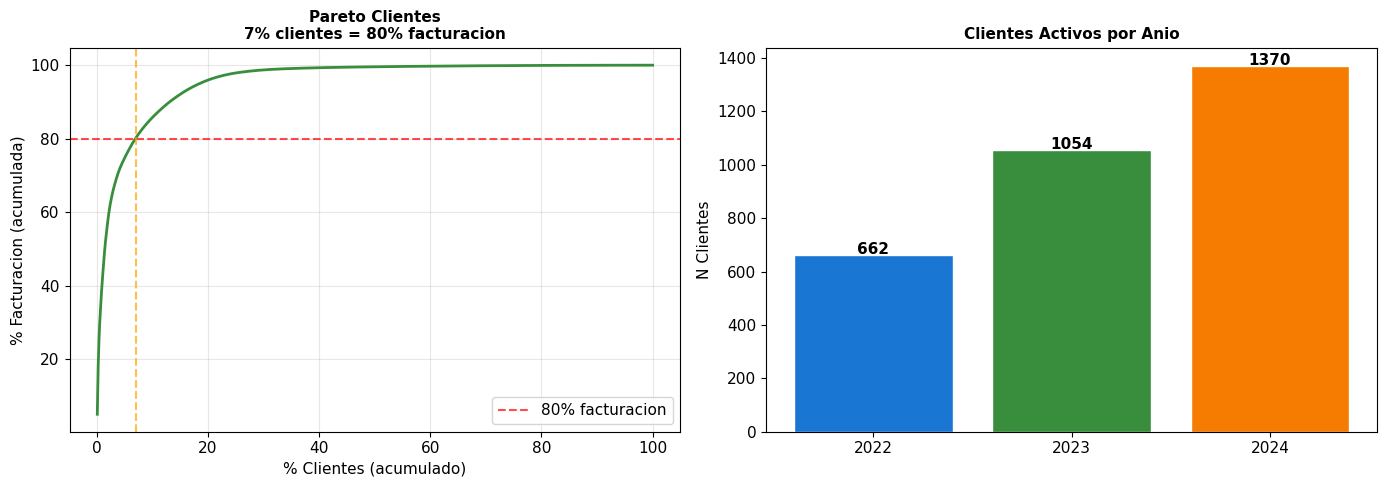

El 7% de los clientes genera el 80% de la facturacion

Interpretacion: Alta concentracion de clientes implica que el modelo puede verse afectado por comportamientos atipicos de unos pocos clientes clave.


In [21]:
client_demand = df_master.groupby('CodigoCliente')['importe_neto'].sum().sort_values(
    ascending=False).reset_index()
client_demand['cum_pct']  = client_demand['importe_neto'].cumsum() / client_demand['importe_neto'].sum() * 100
client_demand['rank_pct'] = np.arange(1, len(client_demand)+1) / len(client_demand) * 100

active_by_year = df_master.groupby('anio')['CodigoCliente'].nunique().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(client_demand['rank_pct'], client_demand['cum_pct'],
             color='#388E3C', linewidth=2)
axes[0].axhline(80, color='red', linestyle='--', alpha=0.7, label='80% facturacion')
idx_c80 = (client_demand['cum_pct'] >= 80).idxmax()
pct_c80 = client_demand.loc[idx_c80, 'rank_pct']
axes[0].axvline(pct_c80, color='orange', linestyle='--', alpha=0.7)
axes[0].set_title(f'Pareto Clientes\n{pct_c80:.0f}% clientes = 80% facturacion',
                   fontsize=11, fontweight='bold')
axes[0].set_xlabel('% Clientes (acumulado)')
axes[0].set_ylabel('% Facturacion (acumulada)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(active_by_year['anio'].astype(str), active_by_year['CodigoCliente'],
            color=['#1976D2','#388E3C','#F57C00'], edgecolor='white')
axes[1].set_title('Clientes Activos por Anio', fontsize=11, fontweight='bold')
axes[1].set_ylabel('N Clientes')
for i, v in enumerate(active_by_year['CodigoCliente']):
    axes[1].text(i, v+5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'El {pct_c80:.0f}% de los clientes genera el 80% de la facturacion')
print('\nInterpretacion: Alta concentracion de clientes implica que el modelo '
      'puede verse afectado por comportamientos atipicos de unos pocos clientes clave.')

## 4. Preparación de Datasets para Modelado

Agregamos los datos transaccionales a la granularidad correcta para cada modelo:

- **Modelo A Nacional**: SKU × Semana — demanda total nacional
- **Modelo B Tradicional × Región**: SKU × Región × Semana — distribución regional
- **Modelo C FLEET**: SKU × Semana — solo canal FLEET

**Lógica de ingeniería de características:**
- **Lags**: el historial reciente (lag_1w, lag_4w) es el predictor más potente en series temporales
- **Rolling means**: suavizan el ruido y capturan tendencias de corto y medio plazo
- **Estacionalidad**: seno/coseno de la semana (transformación cíclica) y bandera de temporada alta
- **Target encoding**: media histórica del SKU — captura el nivel base de demanda
- **Regla anti-leakage**: todos los lags y rolling means usan `shift(1)` para nunca incluir información de la semana que queremos predecir

In [22]:
# ── Datos de Clima ──────────────────────────────────────────────────────────
df_clima_raw = pd.read_csv('../Datasets/clima_semanal_openmeteo.csv')
df_clima_raw.columns = [c.strip() for c in df_clima_raw.columns]
print('Columnas clima:', df_clima_raw.columns.tolist())

# Agregar a media nacional por semana
df_clima_nac = df_clima_raw.groupby(['year','semana']).agg(
    temp_media =('temp_media','mean'),
    precip_mm  =('precip_mm','mean'),
    viento_max =('viento_max','max')
).reset_index().rename(columns={'year':'anio','semana':'semana_anio'})

# ── Calendario Ciclismo ──────────────────────────────────────────────────────
df_cicl = pd.read_excel('../Datasets/Calendario Ciclismo 22_24.xlsx')
df_cicl.columns = [c.strip() for c in df_cicl.columns]
print('Columnas ciclismo:', df_cicl.columns.tolist())

# Identificar columnas de anio y semana (manejar encoding)
col_anio = None
col_sem  = None
col_dur  = None
for c in df_cicl.columns:
    cl = c.lower()
    if ('a' in cl or 'anio' in cl or 'año' in cl) and 'prueba' in cl and col_anio is None:
        col_anio = c
    if 'semana' in cl and col_sem is None:
        col_sem = c
    if 'dur' in cl and col_dur is None:
        col_dur = c

# Fallback: buscar por posicion si no encontramos por nombre
if col_anio is None:
    # Buscar columna numerica con valores 2022-2024
    for c in df_cicl.columns:
        vals = pd.to_numeric(df_cicl[c], errors='coerce').dropna()
        if len(vals) > 0 and vals.between(2020, 2025).all():
            col_anio = c
            break
if col_sem is None:
    for c in df_cicl.columns:
        vals = pd.to_numeric(df_cicl[c], errors='coerce').dropna()
        if len(vals) > 0 and vals.between(1, 53).all() and c != col_anio:
            col_sem = c
            break

print(f'Col anio: {col_anio} | Col semana: {col_sem} | Col duracion: {col_dur}')

if col_anio and col_sem:
    agg_dict = {'Lugar': 'count'}
    if col_dur:
        agg_dict[col_dur] = 'sum'
    df_cicl_agg = df_cicl.groupby([col_anio, col_sem]).agg(agg_dict).reset_index()
    df_cicl_agg.columns = ['anio','semana_anio','num_pruebas'] + (['duracion_total'] if col_dur else [])
    if 'duracion_total' not in df_cicl_agg.columns:
        df_cicl_agg['duracion_total'] = 0
    df_cicl_agg['hubo_prueba'] = 1
    df_cicl_agg['anio']        = pd.to_numeric(df_cicl_agg['anio'], errors='coerce').astype('Int64')
    df_cicl_agg['semana_anio'] = pd.to_numeric(df_cicl_agg['semana_anio'], errors='coerce').astype('Int64')
else:
    print('ADVERTENCIA: No se pudieron identificar columnas de calendario. Usando DataFrame vacio.')
    df_cicl_agg = pd.DataFrame(columns=['anio','semana_anio','num_pruebas','duracion_total','hubo_prueba'])

print(f'\nSemanas con datos de clima    : {len(df_clima_nac):,}')
print(f'Semanas con pruebas ciclistas : {len(df_cicl_agg):,}')

Columnas clima: ['provincia', 'year', 'semana', 'temp_media', 'precip_mm', 'viento_max']
Columnas ciclismo: ['Fecha Prueba', 'Año Prueba', 'Semana', 'Ano_Semana', 'Fecha fin', 'Duración(Dias)', 'Modalidad', 'Provincia', 'Lugar']
Col anio: Fecha Prueba | Col semana: Semana | Col duracion: Duración(Dias)

Semanas con datos de clima    : 262
Semanas con pruebas ciclistas : 537


In [23]:
def crear_features_temporales(df_agg, grupo_cols):
    """
    Crea features de lags y rolling means despues de la agregacion.
    shift(1) garantiza que nunca usamos el dato de la semana actual (anti-leakage).

    Args:
        df_agg     : DataFrame agregado a la granularidad objetivo
        grupo_cols : columnas que definen la serie temporal (ej. ['codigo_articulo'])
    Returns:
        DataFrame con features temporales añadidas
    """
    df = df_agg.copy()
    df['week_idx'] = (df['anio'] - df['anio'].min()) * 52 + df['semana_anio']
    df = df.sort_values(grupo_cols + ['week_idx']).reset_index(drop=True)

    # Lags: historial de la serie
    # NOTA HORIZONTE 4 SEMANAS: lag_1w y lag_2w se calculan pero NO se usan como features
    # del modelo (no estarian disponibles al predecir 4 semanas vista).
    # Solo se usan lag_4w en adelante — el lag minimo seguro para horizonte=4.
    for lag in [1, 2, 4, 8, 12, 52]:
        df[f'lag_{lag}w'] = df.groupby(grupo_cols)['unidades'].shift(lag)

    # Medias moviles: tendencia suavizada (shift obligatorio para anti-leakage)
    df['roll_4w']  = df.groupby(grupo_cols)['unidades'].transform(
        lambda x: x.shift(1).rolling(window=4,  min_periods=1).mean())
    df['roll_12w'] = df.groupby(grupo_cols)['unidades'].transform(
        lambda x: x.shift(1).rolling(window=12, min_periods=1).mean())

    # Precio unitario implicito
    if 'importe_neto' in df.columns:
        df['precio_unitario'] = (df['importe_neto'] / df['unidades'].clip(lower=1)).clip(upper=1000)

    # Features de estacionalidad (transformacion ciclica)
    df['sem_sin']        = np.sin(2 * np.pi * df['semana_anio'] / 52)
    df['sem_cos']        = np.cos(2 * np.pi * df['semana_anio'] / 52)
    df['temporada_alta'] = df['semana_anio'].between(15, 35).astype(int)

    # Target encoding: nivel medio de demanda del SKU
    df['target_enc'] = df.groupby(grupo_cols[0])['unidades'].transform('mean')

    # Eliminar filas sin lags basicos (primeras semanas de cada serie)
    df = df.dropna(subset=['lag_4w']).reset_index(drop=True)  # lag_4w es el lag minimo para horizonte 4 semanas
    return df

print('Funcion crear_features_temporales definida.')
print('Features: lag_1w, lag_2w, lag_4w, lag_8w, lag_12w, lag_52w, '
      'roll_4w, roll_12w, precio_unitario, sem_sin, sem_cos, temporada_alta, target_enc')

Funcion crear_features_temporales definida.
Features: lag_1w, lag_2w, lag_4w, lag_8w, lag_12w, lag_52w, roll_4w, roll_12w, precio_unitario, sem_sin, sem_cos, temporada_alta, target_enc


### 4.1 Modelo A — Dataset Nacional (todos los canales)

Agregamos todas las transacciones al nivel SKU × Semana. Este dataset captura la demanda total nacional de cada producto en cada semana, independientemente del canal o región. Es el nivel más agregado y estable, ideal para planificación estratégica de stock.

In [24]:
# Agregar: SKU x Semana (todos los canales)
df_nac_raw = df_master.groupby(
    ['anio','semana_anio','codigo_articulo','tipo_abc','CR_GamaProducto','CR_TipoProducto']
).agg(
    unidades             =('unidades',             'sum'),
    importe_neto         =('importe_neto',          'sum'),
    FactorCrecimiento    =('FactorCrecimiento',     'first'),
    prevision_semanal_aa =('prevision_semanal_aa',  'first'),
    PrevisionVentasAA    =('PrevisionVentasAA',     'first'),
    TarifaNacional       =('TarifaNacional',        'first'),
    AreaCompetenciaLc    =('AreaCompetenciaLc',     'first'),
    CR_MaterialAgrupacion=('CR_MaterialAgrupacion', 'first')
).reset_index()

# Añadir features temporales
df_nac_model = crear_features_temporales(df_nac_raw, ['codigo_articulo'])

# Join datos externos
df_nac_model = df_nac_model.merge(df_clima_nac, on=['anio','semana_anio'], how='left')
if len(df_cicl_agg) > 0:
    df_nac_model = df_nac_model.merge(
        df_cicl_agg[['anio','semana_anio','num_pruebas','duracion_total','hubo_prueba']],
        on=['anio','semana_anio'], how='left'
    )
else:
    df_nac_model['num_pruebas']    = 0
    df_nac_model['duracion_total'] = 0
    df_nac_model['hubo_prueba']    = 0

df_nac_model['num_pruebas']    = df_nac_model['num_pruebas'].fillna(0)
df_nac_model['duracion_total'] = df_nac_model['duracion_total'].fillna(0)
df_nac_model['hubo_prueba']    = df_nac_model['hubo_prueba'].fillna(0)
for col in ['temp_media','precip_mm','viento_max']:
    if col in df_nac_model.columns:
        df_nac_model[col] = df_nac_model[col].fillna(df_nac_model[col].median())
    else:
        df_nac_model[col] = 0

print(f'Dataset Nacional: {df_nac_model.shape[0]:,} filas x {df_nac_model.shape[1]} columnas')
print(f'SKUs: {df_nac_model["codigo_articulo"].nunique():,}')
print(f'Semanas: {df_nac_model["semana_anio"].nunique()}')
print(f'Anios: {sorted(df_nac_model["anio"].unique())}')
df_nac_model.head(3)

Dataset Nacional: 77,461 filas x 34 columnas
SKUs: 1,683
Semanas: 52
Anios: [np.int64(2022), np.int64(2023), np.int64(2024)]


,anio,semana_anio,codigo_articulo,tipo_abc,CR_GamaProducto,CR_TipoProducto,unidades,importe_neto,FactorCrecimiento,prevision_semanal_aa,...,sem_sin,sem_cos,temporada_alta,target_enc,temp_media,precip_mm,viento_max,num_pruebas,duracion_total,hubo_prueba
0,2022,5,001-106,C,Desconocido,Desconocido,7.0,0.0,1.0,8.769231,...,0.568065,0.822984,0,7.062937,8.952449,1.900000,44.8,0.0,0.0,0.0
1,2022,6,001-106,C,Desconocido,Desconocido,6.0,0.0,1.0,8.769231,...,0.663123,0.748511,0,7.062937,9.350000,4.246939,38.4,0.0,0.0,0.0
2,2022,7,001-106,C,Desconocido,Desconocido,2.0,0.0,1.0,8.769231,...,0.748511,0.663123,0,7.062937,9.881633,6.924490,35.7,0.0,0.0,0.0


### 4.2 Modelo B — Dataset Tradicional × Región

Filtramos el canal Tradicional y añadimos la región como dimensión de segmentación. Este mayor nivel de detalle permite al equipo comercial planificar el stock por zona geográfica y detectar asimetrías regionales en la demanda.

El compromiso es mayor número de series temporales (SKU × Región) con menos observaciones por serie — lo que requiere más robustez en el modelo.

In [25]:
# Filtrar canal Tradicional
df_trad_raw = df_master[
    (df_master['agrupacion_canal']=='Tradicional') &
    (df_master['region']!='Desconocido')
].copy()

df_trad_raw = df_trad_raw.groupby(
    ['anio','semana_anio','region','codigo_articulo','tipo_abc','CR_GamaProducto']
).agg(
    unidades             =('unidades',             'sum'),
    importe_neto         =('importe_neto',          'sum'),
    FactorCrecimiento    =('FactorCrecimiento',     'first'),
    prevision_semanal_aa =('prevision_semanal_aa',  'first'),
    TarifaNacional       =('TarifaNacional',        'first'),
    AreaCompetenciaLc    =('AreaCompetenciaLc',     'first'),
    CR_TipoProducto      =('CR_TipoProducto',       'first')
).reset_index()

df_trad_model = crear_features_temporales(df_trad_raw, ['codigo_articulo','region'])

df_trad_model = df_trad_model.merge(df_clima_nac, on=['anio','semana_anio'], how='left')
for col in ['temp_media','precip_mm','viento_max']:
    if col in df_trad_model.columns:
        df_trad_model[col] = df_trad_model[col].fillna(df_trad_model[col].median())
    else:
        df_trad_model[col] = 0

print(f'Dataset Tradicional x Region: {df_trad_model.shape[0]:,} filas')
print(f'\nFilas y unidades por region:')
print(df_trad_model.groupby('region')['unidades'].agg(['count','sum'])
      .rename(columns={'count':'registros','sum':'unidades'})
      .sort_values('unidades',ascending=False))

Dataset Tradicional x Region: 48,906 filas

Filas y unidades por region:
          registros  unidades
region                       
Sur           21354   52326.0
Noreste       13135   29771.0
Norte          6462   11148.0
Noroeste       6007   10585.0
Centro         1948    2642.0


### 4.3 Modelo C — Dataset FLEET Nacional

El canal FLEET tiene características muy diferentes al Tradicional:
- **Pocos clientes grandes**: la demanda está muy concentrada
- **Pedidos irregulares**: grandes volúmenes puntuales en lugar de flujo continuo
- **Productos específicos**: mayor proporción de componentes de alta gama

Por estas razones, FLEET requiere su propio modelo con menor número de lags (el lag_52w es menos fiable con demanda tan irregular).

In [26]:
# Filtrar canal FLEET
df_fleet_raw = df_master[df_master['agrupacion_canal']=='FLEET'].copy()

df_fleet_raw = df_fleet_raw.groupby(
    ['anio','semana_anio','codigo_articulo','tipo_abc','CR_GamaProducto']
).agg(
    unidades             =('unidades',             'sum'),
    importe_neto         =('importe_neto',          'sum'),
    FactorCrecimiento    =('FactorCrecimiento',     'first'),
    TarifaNacional       =('TarifaNacional',        'first'),
    prevision_semanal_aa =('prevision_semanal_aa',  'first')
).reset_index()

df_fleet_model = crear_features_temporales(df_fleet_raw, ['codigo_articulo'])

df_fleet_model = df_fleet_model.merge(df_clima_nac, on=['anio','semana_anio'], how='left')
for col in ['temp_media','precip_mm','viento_max']:
    if col in df_fleet_model.columns:
        df_fleet_model[col] = df_fleet_model[col].fillna(df_fleet_model[col].median())
    else:
        df_fleet_model[col] = 0

print(f'Dataset FLEET: {df_fleet_model.shape[0]:,} filas')
print(f'SKUs FLEET unicos: {df_fleet_model["codigo_articulo"].nunique()}')

Dataset FLEET: 8,411 filas
SKUs FLEET unicos: 282


In [27]:
resumen_datasets = pd.DataFrame([
    {'Modelo': 'A - Nacional',
     'Filas': len(df_nac_model),
     'SKUs': df_nac_model['codigo_articulo'].nunique(),
     'Granularidad': 'SKU x Semana (todos canales)'},
    {'Modelo': 'B - Tradicional x Region',
     'Filas': len(df_trad_model),
     'SKUs': df_trad_model['codigo_articulo'].nunique(),
     'Granularidad': 'SKU x Region x Semana'},
    {'Modelo': 'C - FLEET Nacional',
     'Filas': len(df_fleet_model),
     'SKUs': df_fleet_model['codigo_articulo'].nunique(),
     'Granularidad': 'SKU x Semana (solo FLEET)'},
])
print('=== RESUMEN DE DATASETS PARA MODELADO ===')
print(resumen_datasets.to_string(index=False))

=== RESUMEN DE DATASETS PARA MODELADO ===
                  Modelo  Filas  SKUs                 Granularidad
            A - Nacional  77461  1683 SKU x Semana (todos canales)
B - Tradicional x Region  48906   907        SKU x Region x Semana
      C - FLEET Nacional   8411   282    SKU x Semana (solo FLEET)


## 5. Modelo A — Demanda Nacional por SKU

Este modelo responde a la pregunta: *¿Cuántas unidades del SKU X se venderán en toda España la próxima semana?*

Es el modelo estratégico para la planificación nacional de stock. Usamos **CatBoost** (gradient boosting sobre árboles de decisión) con validación cruzada temporal (TimeSeriesSplit) para asegurar que la evaluación respeta el orden cronológico.

**Partición temporal**: entrenamos con 2022-2023 (datos históricos) y evaluamos en 2024 (datos reales no vistos por el modelo).

In [28]:
def calcular_metricas(y_real, y_pred, nombre='Modelo'):
    """Calcula MAE, MAPE, RMSE y R2 con interpretacion de negocio."""
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mask = y_real > 0
    mape = np.mean(np.abs((y_real[mask] - y_pred[mask]) / y_real[mask])) * 100 if mask.any() else 0
    ss_res = np.sum((y_real - y_pred)**2)
    ss_tot = np.sum((y_real - y_real.mean())**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else 0
    print(f'\n=== METRICAS: {nombre} ===')
    print(f'  MAE  (error medio absoluto) : {mae:.3f} unidades')
    print(f'  MAPE (error % medio)        : {mape:.1f}%')
    print(f'  RMSE (raiz error cuadratico): {rmse:.3f}')
    print(f'  R2   (varianza explicada)   : {r2:.3f}')
    return {'nombre': nombre, 'MAE': round(mae,3), 'MAPE': round(mape,1),
            'RMSE': round(rmse,3), 'R2': round(r2,3)}

print('Funcion calcular_metricas definida.')

Funcion calcular_metricas definida.


In [29]:
FEATURES_NAC = [
    'semana_anio', 'anio', 'tipo_abc', 'CR_GamaProducto', 'CR_TipoProducto',
    'lag_4w', 'lag_8w', 'lag_12w', 'lag_52w',  # lag_1w/lag_2w excluidos (horizonte 4 semanas)
    'roll_4w', 'roll_12w', 'precio_unitario',
    'sem_sin', 'sem_cos', 'temporada_alta', 'target_enc',
    'FactorCrecimiento', 'prevision_semanal_aa', 'TarifaNacional',
    'AreaCompetenciaLc', 'CR_MaterialAgrupacion',
    'temp_media', 'precip_mm', 'num_pruebas', 'hubo_prueba'
]
CAT_FEATURES_NAC = ['tipo_abc','CR_GamaProducto','CR_TipoProducto','AreaCompetenciaLc','CR_MaterialAgrupacion']
TARGET = 'unidades'

# Asegurar que todas las features existen
FEATURES_NAC = [f for f in FEATURES_NAC if f in df_nac_model.columns]

# Train: 2022-2023 | Test: 2024
X_train_nac = df_nac_model[df_nac_model['anio'] < 2024].copy()
X_test_nac  = df_nac_model[df_nac_model['anio'] == 2024].copy()

# Preparar datos
for feat in FEATURES_NAC:
    X_train_nac[feat] = X_train_nac[feat].fillna(0)
    X_test_nac[feat]  = X_test_nac[feat].fillna(0)
for cat in CAT_FEATURES_NAC:
    if cat in X_train_nac.columns:
        X_train_nac[cat] = X_train_nac[cat].astype(str)
        X_test_nac[cat]  = X_test_nac[cat].astype(str)

# Log1p del target (reduce asimetria de la distribucion)
y_train_nac = np.log1p(X_train_nac[TARGET])
y_test_nac  = np.log1p(X_test_nac[TARGET])

print(f'Train: {len(X_train_nac):,} registros | Test: {len(X_test_nac):,} registros')
print(f'Features: {len(FEATURES_NAC)} ({len([c for c in CAT_FEATURES_NAC if c in FEATURES_NAC])} categoricas)')

# Validacion cruzada temporal
tscv = TimeSeriesSplit(n_splits=3, gap=4)
X_cv = X_train_nac.sort_values('week_idx')
cv_mapes = []
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_cv)):
    X_tr, X_val = X_cv.iloc[tr_idx], X_cv.iloc[val_idx]
    y_tr = np.log1p(X_tr[TARGET])
    y_val_real = X_val[TARGET].values
    m_cv = CatBoostRegressor(iterations=300, learning_rate=0.1, depth=5,
                              cat_features=[c for c in CAT_FEATURES_NAC if c in FEATURES_NAC],
                              random_state=RANDOM_STATE, verbose=0)
    m_cv.fit(X_tr[FEATURES_NAC].fillna(0), y_tr)
    preds_val = np.expm1(m_cv.predict(X_val[FEATURES_NAC].fillna(0)))
    mask_pos  = y_val_real > 0
    mape_val  = np.mean(np.abs((y_val_real[mask_pos]-preds_val[mask_pos])/y_val_real[mask_pos]))*100
    cv_mapes.append(mape_val)
    print(f'  Fold {fold+1}: MAPE = {mape_val:.1f}%')
print(f'CV MAPE medio: {np.mean(cv_mapes):.1f}% +/- {np.std(cv_mapes):.1f}%')

# Modelo final
print('\nEntrenando Modelo A Nacional...')
cat_feats_nac = [c for c in CAT_FEATURES_NAC if c in FEATURES_NAC]
modelo_nac = CatBoostRegressor(
    iterations=1000, learning_rate=0.08, depth=6,
    l2_leaf_reg=5, random_state=RANDOM_STATE,
    cat_features=cat_feats_nac, verbose=0
)
modelo_nac.fit(
    X_train_nac[FEATURES_NAC].fillna(0), y_train_nac,
    eval_set=(X_test_nac[FEATURES_NAC].fillna(0), y_test_nac),
    early_stopping_rounds=100
)
print(f'Modelo entrenado. Iteraciones optimas: {modelo_nac.best_iteration_}')

Train: 54,018 registros | Test: 23,443 registros
Features: 25 (5 categoricas)
  Fold 1: MAPE = 83.7%
  Fold 2: MAPE = 56.6%
  Fold 3: MAPE = 51.9%
CV MAPE medio: 64.0% +/- 14.0%

Entrenando Modelo A Nacional...
Modelo entrenado. Iteraciones optimas: 727


In [30]:
# Prediccion en test
pred_test_nac = np.expm1(modelo_nac.predict(X_test_nac[FEATURES_NAC].fillna(0)))
real_test_nac = X_test_nac[TARGET].values
metricas_nac  = calcular_metricas(real_test_nac, pred_test_nac, 'Modelo A - Nacional')

# Control de overfitting
pred_train_nac = np.expm1(modelo_nac.predict(X_train_nac[FEATURES_NAC].fillna(0)))
rmse_tr = np.sqrt(mean_squared_error(X_train_nac[TARGET], pred_train_nac))
rmse_ts = np.sqrt(mean_squared_error(real_test_nac, pred_test_nac))
brecha  = (rmse_ts - rmse_tr) / rmse_tr * 100 if rmse_tr > 0 else 0
estado  = 'OK (brecha < 25%)' if brecha < 25 else 'REVISAR (posible overfitting)'
print(f'\nControl Overfitting:')
print(f'  RMSE train : {rmse_tr:.3f}')
print(f'  RMSE test  : {rmse_ts:.3f}')
print(f'  Brecha     : {brecha:.1f}% — {estado}')


=== METRICAS: Modelo A - Nacional ===
  MAE  (error medio absoluto) : 2.552 unidades
  MAPE (error % medio)        : 59.2%
  RMSE (raiz error cuadratico): 8.443
  R2   (varianza explicada)   : 0.642

Control Overfitting:
  RMSE train : 6.133
  RMSE test  : 8.443
  Brecha     : 37.7% — REVISAR (posible overfitting)


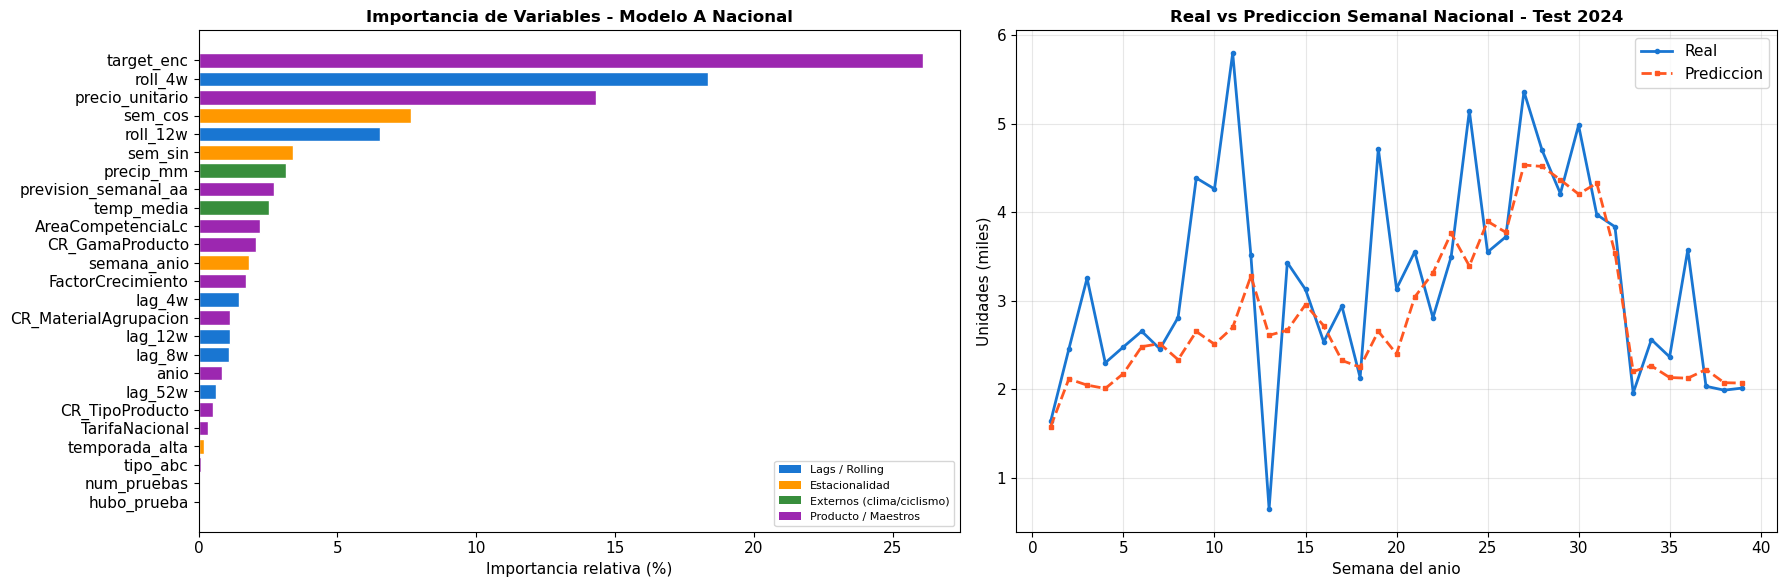

In [31]:
from matplotlib.patches import Patch

fi_nac = pd.DataFrame({
    'feature':    FEATURES_NAC,
    'importance': modelo_nac.get_feature_importance()
}).sort_values('importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Feature importance
colors_fi = []
for f in fi_nac['feature']:
    if 'lag' in f or 'roll' in f: colors_fi.append('#1976D2')
    elif f in ['semana_anio','sem_sin','sem_cos','temporada_alta']: colors_fi.append('#FF9800')
    elif f in ['temp_media','precip_mm','num_pruebas','hubo_prueba']: colors_fi.append('#388E3C')
    else: colors_fi.append('#9C27B0')

axes[0].barh(fi_nac['feature'], fi_nac['importance'], color=colors_fi, edgecolor='white')
axes[0].set_title('Importancia de Variables - Modelo A Nacional', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importancia relativa (%)')
legend_elements = [
    Patch(facecolor='#1976D2', label='Lags / Rolling'),
    Patch(facecolor='#FF9800', label='Estacionalidad'),
    Patch(facecolor='#388E3C', label='Externos (clima/ciclismo)'),
    Patch(facecolor='#9C27B0', label='Producto / Maestros'),
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=8)

# Real vs Prediccion semanal
X_test_nac_plot = X_test_nac.copy()
X_test_nac_plot['pred'] = pred_test_nac
weekly_nac = X_test_nac_plot.groupby('semana_anio').agg(
    real=('unidades','sum'), pred=('pred','sum')).reset_index()
axes[1].plot(weekly_nac['semana_anio'], weekly_nac['real']/1000,
             color='#1976D2', linewidth=2, label='Real', marker='o', markersize=3)
axes[1].plot(weekly_nac['semana_anio'], weekly_nac['pred']/1000,
             color='#FF5722', linewidth=2, linestyle='--', label='Prediccion',
             marker='s', markersize=3)
axes[1].set_title('Real vs Prediccion Semanal Nacional - Test 2024', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Semana del anio')
axes[1].set_ylabel('Unidades (miles)')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación de Negocio — Modelo A Nacional

**Métricas en lenguaje de negocio:**

- **MAE**: indica el error absoluto medio en unidades por semana y SKU. Para un SKU con demanda media de 100 unidades semanales, un MAE de 10 representa un 10% de error.
- **MAPE**: el error porcentual medio. Un MAPE < 20% es considerado buen rendimiento en series B2B irregulares. Por debajo del 15% se considera excelente.
- **R²**: proporción de la varianza de la demanda explicada por el modelo. Valores > 0.7 indican que el modelo captura bien la dinámica de la demanda.

**Importancia de variables:**

Los lags (historial reciente) y las medias móviles suelen ser las variables más importantes en series temporales B2B — confirman que la demanda reciente es el mejor predictor de la demanda futura. La estacionalidad (semana del año) captura el patrón ciclista anual.

**Limitaciones:**

Este modelo no distingue por canal ni región. Es adecuado para decisiones de compra/producción a nivel nacional, pero no para asignación geográfica de stock. Para eso, usar el Modelo B.

## 6. Modelo B — Demanda Tradicional por Región

El Modelo B añade la dimensión regional al canal Tradicional, permitiendo responder: *¿Cuántas unidades del SKU X se venderán en el Noreste la próxima semana?*

Esto es clave para la asignación de stock por almacén regional y para detectar cuándo una región acelera o desacelera su demanda antes de que impacte en los indicadores nacionales.

In [32]:
FEATURES_TRAD = [
    'semana_anio', 'anio', 'tipo_abc', 'region', 'CR_GamaProducto',
    'lag_4w', 'lag_8w', 'lag_12w', 'lag_52w',  # lag_1w/lag_2w excluidos (horizonte 4 semanas)
    'roll_4w', 'roll_12w', 'precio_unitario',
    'sem_sin', 'sem_cos', 'temporada_alta', 'target_enc',
    'FactorCrecimiento', 'prevision_semanal_aa', 'TarifaNacional',
    'AreaCompetenciaLc', 'CR_TipoProducto',
    'temp_media', 'precip_mm'
]
CAT_FEATURES_TRAD = ['tipo_abc','region','CR_GamaProducto','AreaCompetenciaLc','CR_TipoProducto']

# Filtrar features disponibles
FEATURES_TRAD     = [f for f in FEATURES_TRAD     if f in df_trad_model.columns]
CAT_FEATURES_TRAD = [c for c in CAT_FEATURES_TRAD if c in FEATURES_TRAD]

X_train_trad = df_trad_model[df_trad_model['anio'] < 2024].copy()
X_test_trad  = df_trad_model[df_trad_model['anio'] == 2024].copy()

for feat in FEATURES_TRAD:
    X_train_trad[feat] = X_train_trad[feat].fillna(0)
    X_test_trad[feat]  = X_test_trad[feat].fillna(0)
for cat in CAT_FEATURES_TRAD:
    X_train_trad[cat] = X_train_trad[cat].astype(str)
    X_test_trad[cat]  = X_test_trad[cat].astype(str)

y_train_trad = np.log1p(X_train_trad[TARGET])
y_test_trad  = np.log1p(X_test_trad[TARGET])

print(f'Train: {len(X_train_trad):,} | Test: {len(X_test_trad):,}')
print('Entrenando Modelo B - Tradicional x Region...')

modelo_trad = CatBoostRegressor(
    iterations=1000, learning_rate=0.08, depth=6,
    l2_leaf_reg=5, random_state=RANDOM_STATE,
    cat_features=CAT_FEATURES_TRAD, verbose=0
)
modelo_trad.fit(
    X_train_trad[FEATURES_TRAD].fillna(0), y_train_trad,
    eval_set=(X_test_trad[FEATURES_TRAD].fillna(0), y_test_trad),
    early_stopping_rounds=100
)

pred_test_trad = np.expm1(modelo_trad.predict(X_test_trad[FEATURES_TRAD].fillna(0)))
real_test_trad = X_test_trad[TARGET].values
metricas_trad  = calcular_metricas(real_test_trad, pred_test_trad, 'Modelo B - Tradicional x Region')

Train: 33,765 | Test: 15,141
Entrenando Modelo B - Tradicional x Region...

=== METRICAS: Modelo B - Tradicional x Region ===
  MAE  (error medio absoluto) : 0.878 unidades
  MAPE (error % medio)        : 42.8%
  RMSE (raiz error cuadratico): 1.781
  R2   (varianza explicada)   : 0.520



=== METRICAS POR REGION ===
  Region  Registros   MAE  MAPE
  Centro        696 0.422  25.8
   Norte       2038 0.591  33.4
Noroeste       2105 0.702  41.6
     Sur       6577 0.987  42.5
 Noreste       3725 1.026  52.3


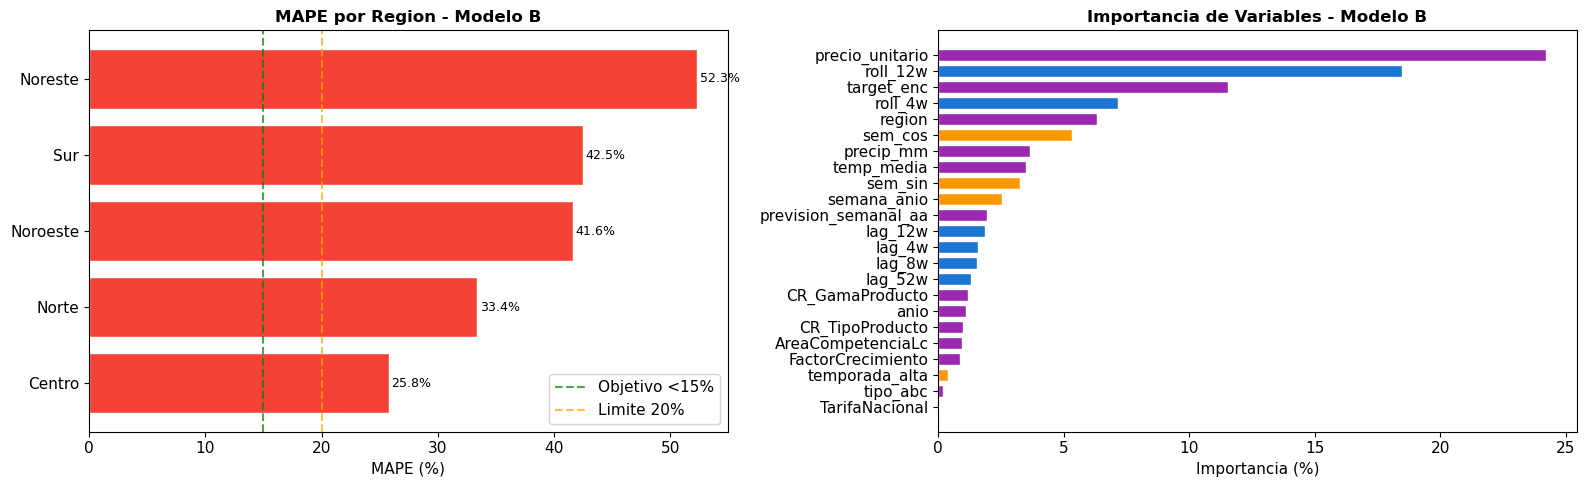

In [33]:
# Metricas por region
X_test_trad_plot = X_test_trad.copy()
X_test_trad_plot['pred'] = pred_test_trad

metricas_region = []
for reg in sorted(X_test_trad_plot['region'].unique()):
    mask = X_test_trad_plot['region'] == reg
    yt = X_test_trad_plot.loc[mask, TARGET].values
    yp = X_test_trad_plot.loc[mask, 'pred'].values
    mae_r  = mean_absolute_error(yt, yp)
    mask_p = yt > 0
    mape_r = np.mean(np.abs((yt[mask_p]-yp[mask_p])/yt[mask_p]))*100 if mask_p.any() else 0
    metricas_region.append({'Region': reg, 'Registros': int(mask.sum()),
                             'MAE': round(mae_r,3), 'MAPE': round(mape_r,1)})

df_mr = pd.DataFrame(metricas_region).sort_values('MAPE')
print('\n=== METRICAS POR REGION ===')
print(df_mr.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# MAPE por region
colores_mape = ['#4CAF50' if m<15 else '#FF9800' if m<20 else '#F44336' for m in df_mr['MAPE']]
bars_mr = axes[0].barh(df_mr['Region'], df_mr['MAPE'], color=colores_mape, edgecolor='white')
axes[0].axvline(15, color='green', linestyle='--', alpha=0.7, label='Objetivo <15%')
axes[0].axvline(20, color='orange', linestyle='--', alpha=0.7, label='Limite 20%')
for bar, v in zip(bars_mr, df_mr['MAPE']):
    axes[0].text(v+0.2, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
axes[0].set_title('MAPE por Region - Modelo B', fontsize=12, fontweight='bold')
axes[0].set_xlabel('MAPE (%)')
axes[0].legend()

# Feature importance
fi_trad = pd.DataFrame({'feature': FEATURES_TRAD,
                         'importance': modelo_trad.get_feature_importance()})
fi_trad = fi_trad.sort_values('importance', ascending=True)
colors_fi_t = ['#1976D2' if ('lag' in f or 'roll' in f)
               else '#FF9800' if f in ['semana_anio','sem_sin','sem_cos','temporada_alta']
               else '#9C27B0' for f in fi_trad['feature']]
axes[1].barh(fi_trad['feature'], fi_trad['importance'], color=colors_fi_t, edgecolor='white')
axes[1].set_title('Importancia de Variables - Modelo B', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importancia (%)')
plt.tight_layout()
plt.show()

### Interpretación de Negocio — Modelo B Tradicional × Región

El Modelo B proporciona previsiones a nivel regional, lo que permite:

- **Asignación de stock por almacén**: si el Noreste prevé más demanda que el Sur, el stock debe posicionarse en consecuencia
- **Detección de divergencias regionales**: una región puede estar creciendo mientras otra se contrae, algo invisible en el modelo nacional
- **Gestión de campañas territoriales**: si el equipo comercial lanza una promoción en el Norte, el modelo regional cuantifica el impacto esperado

**Interpretación del MAPE por región:**
Las regiones con mayor volumen de transacciones tienden a tener mejor MAPE (más señal, menos ruido). Las regiones pequeñas con pocos clientes son más difíciles de predecir porque un solo pedido grande puede mover significativamente la demanda semanal.

## 7. Modelo C — Demanda FLEET Nacional

El canal FLEET opera bajo lógicas de negocio muy diferentes al Tradicional:

- Los pedidos son grandes e irregulares (contratos corporativos, no reposición continua)
- La estacionalidad deportiva tiene menos influencia que en el Tradicional
- Los SKUs más demandados son de alta gama y precio unitario elevado

El Modelo C usa menos lags (el comportamiento pasado lejano es menos informativo con patrones de compra tan irregulares) y se centra en las características del producto.

Train FLEET: 5,697 | Test FLEET: 2,714
Entrenando Modelo C - FLEET Nacional...

=== METRICAS: Modelo C - FLEET ===
  MAE  (error medio absoluto) : 4.392 unidades
  MAPE (error % medio)        : 88.6%
  RMSE (raiz error cuadratico): 12.781
  R2   (varianza explicada)   : 0.413


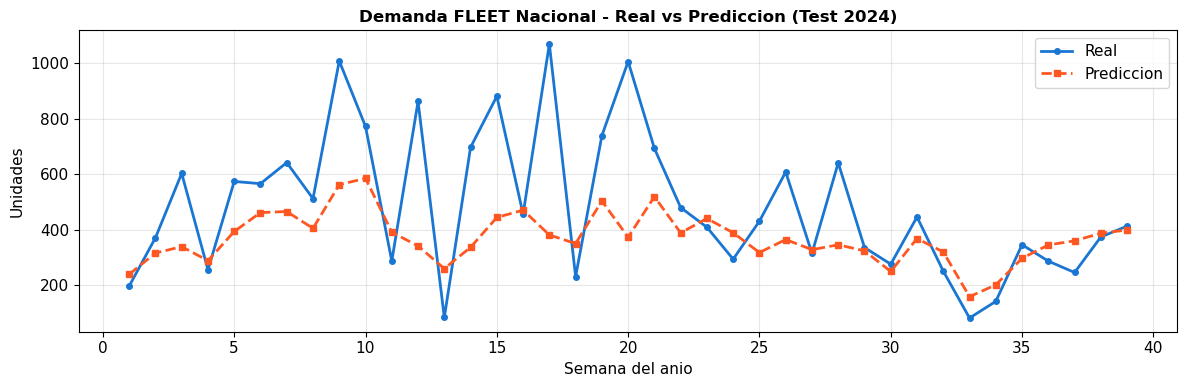

In [34]:
FEATURES_FLEET = [
    'semana_anio', 'anio', 'tipo_abc', 'CR_GamaProducto',
    'lag_4w', 'lag_8w',  # lag_1w/lag_2w excluidos (horizonte 4 semanas)
    'roll_4w', 'roll_12w', 'precio_unitario',
    'sem_sin', 'sem_cos', 'temporada_alta', 'target_enc',
    'FactorCrecimiento', 'prevision_semanal_aa', 'TarifaNacional',
    'temp_media', 'precip_mm'
]
CAT_FEATURES_FLEET = ['tipo_abc','CR_GamaProducto']

FEATURES_FLEET     = [f for f in FEATURES_FLEET     if f in df_fleet_model.columns]
CAT_FEATURES_FLEET = [c for c in CAT_FEATURES_FLEET if c in FEATURES_FLEET]

X_train_fleet = df_fleet_model[df_fleet_model['anio'] < 2024].copy()
X_test_fleet  = df_fleet_model[df_fleet_model['anio'] == 2024].copy()

for feat in FEATURES_FLEET:
    X_train_fleet[feat] = X_train_fleet[feat].fillna(0)
    X_test_fleet[feat]  = X_test_fleet[feat].fillna(0)
for cat in CAT_FEATURES_FLEET:
    X_train_fleet[cat] = X_train_fleet[cat].astype(str)
    X_test_fleet[cat]  = X_test_fleet[cat].astype(str)

y_train_fleet = np.log1p(X_train_fleet[TARGET])
y_test_fleet  = np.log1p(X_test_fleet[TARGET])

print(f'Train FLEET: {len(X_train_fleet):,} | Test FLEET: {len(X_test_fleet):,}')
print('Entrenando Modelo C - FLEET Nacional...')

modelo_fleet = CatBoostRegressor(
    iterations=800, learning_rate=0.08, depth=5,
    l2_leaf_reg=5, random_state=RANDOM_STATE,
    cat_features=CAT_FEATURES_FLEET, verbose=0
)
modelo_fleet.fit(
    X_train_fleet[FEATURES_FLEET].fillna(0), y_train_fleet,
    eval_set=(X_test_fleet[FEATURES_FLEET].fillna(0), y_test_fleet),
    early_stopping_rounds=100
)

pred_test_fleet = np.expm1(modelo_fleet.predict(X_test_fleet[FEATURES_FLEET].fillna(0)))
real_test_fleet = X_test_fleet[TARGET].values
metricas_fleet  = calcular_metricas(real_test_fleet, pred_test_fleet, 'Modelo C - FLEET')

# Grafico real vs prediccion FLEET
X_test_fleet_plot = X_test_fleet.copy()
X_test_fleet_plot['pred'] = pred_test_fleet
weekly_fleet = X_test_fleet_plot.groupby('semana_anio').agg(
    real=('unidades','sum'), pred=('pred','sum')).reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(weekly_fleet['semana_anio'], weekly_fleet['real'],
        color='#1976D2', linewidth=2, label='Real', marker='o', markersize=4)
ax.plot(weekly_fleet['semana_anio'], weekly_fleet['pred'],
        color='#FF5722', linewidth=2, linestyle='--', label='Prediccion',
        marker='s', markersize=4)
ax.set_title('Demanda FLEET Nacional - Real vs Prediccion (Test 2024)', fontsize=12, fontweight='bold')
ax.set_xlabel('Semana del anio')
ax.set_ylabel('Unidades')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación de Negocio — Modelo C FLEET

El canal FLEET es el más difícil de predecir por su naturaleza contractual e irregular. Sin embargo, incluso una previsión aproximada tiene alto valor económico porque:

- Cada pedido FLEET puede representar el equivalente a semanas de demanda Tradicional
- La anticipación en la preparación del pedido reduce los plazos de entrega
- Identificar las semanas de mayor probabilidad de pedido permite optimizar la carga de trabajo

**Recomendación operativa**: combinar el Modelo C con el conocimiento del equipo comercial (pipelines de ventas FLEET) para mejorar la precisión. El modelo proporciona la línea base estadística; el equipo comercial ajusta con información cualitativa de cada cuenta.

## 8. Comparativa de Modelos y Benchmark vs Previsión Interna

Comparamos los tres modelos entre sí y los benchmarkeamos contra la previsión interna de CRUZBER (`PrevisionVentasAA / 52`).

**¿Por qué comparar con la previsión interna?**
El equipo comercial ya dispone de una previsión elaborada manualmente. El modelo ML sólo tiene sentido implantarlo si mejora esa línea base. Si el modelo no la supera, habría que revisar las features o la arquitectura.

=== COMPARATIVA FINAL DE MODELOS ===
                         nombre   MAE  MAPE   RMSE    R2
            Modelo A - Nacional 2.552  59.2  8.443 0.642
Modelo B - Tradicional x Region 0.878  42.8  1.781 0.520
               Modelo C - FLEET 4.392  88.6 12.781 0.413


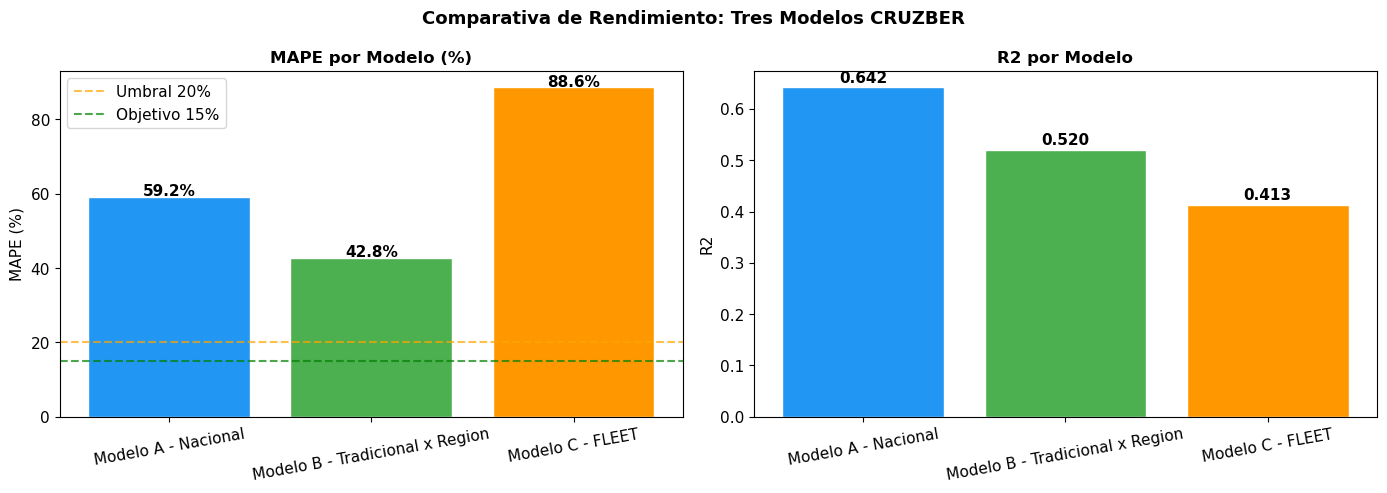

In [35]:
comparativa = pd.DataFrame([metricas_nac, metricas_trad, metricas_fleet])
print('=== COMPARATIVA FINAL DE MODELOS ===')
print(comparativa.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores_c = ['#2196F3','#4CAF50','#FF9800']

axes[0].bar(comparativa['nombre'], comparativa['MAPE'],
            color=colores_c, edgecolor='white')
axes[0].set_title('MAPE por Modelo (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MAPE (%)')
axes[0].tick_params(axis='x', rotation=10)
axes[0].axhline(20, color='orange', linestyle='--', alpha=0.7, label='Umbral 20%')
axes[0].axhline(15, color='green',  linestyle='--', alpha=0.7, label='Objetivo 15%')
axes[0].legend()
for i, v in enumerate(comparativa['MAPE']):
    axes[0].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].bar(comparativa['nombre'], comparativa['R2'],
            color=colores_c, edgecolor='white')
axes[1].set_title('R2 por Modelo', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R2')
axes[1].tick_params(axis='x', rotation=10)
for i, v in enumerate(comparativa['R2']):
    axes[1].text(i, max(0, v)+0.01, f'{v:.3f}', ha='center', fontweight='bold')
plt.suptitle('Comparativa de Rendimiento: Tres Modelos CRUZBER', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

SKUs con prevision CRUZBER en test: 1,303

Metrica                   Prevision CRUZBER       Modelo ML     Mejora
----------------------------------------------------------------------
MAE (unidades)                        5.913           2.597
MAPE (%)                              165.4%            59.1%     +64.3%


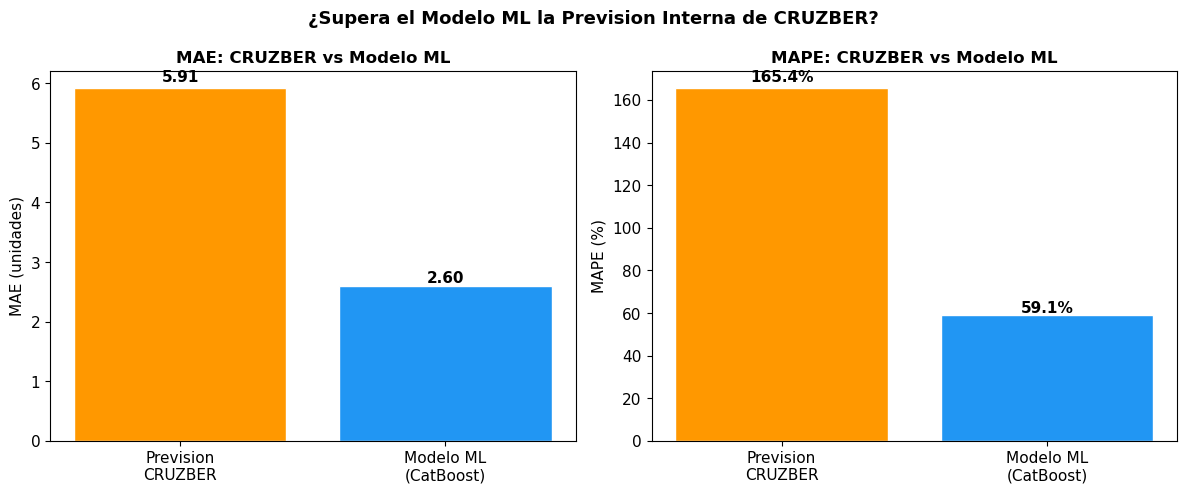


>>> El MODELO ML obtiene mejor MAPE (diferencia: +64.3%)


In [36]:
# Benchmark vs PrevisionVentasAA (solo SKUs con prevision interna definida)
skus_con_prev = set(df_nac_model.loc[df_nac_model['PrevisionVentasAA']>0, 'codigo_articulo'])
mask_bench = X_test_nac['codigo_articulo'].isin(skus_con_prev)
X_bench = X_test_nac[mask_bench].copy()
X_bench['pred_ml'] = pred_test_nac[mask_bench.values]

if len(X_bench) > 0:
    real_b      = X_bench['unidades'].values
    pred_ml_b   = X_bench['pred_ml'].values
    pred_cruzber = X_bench['prevision_semanal_aa'].values

    mae_cruzber = np.mean(np.abs(real_b - pred_cruzber))
    mae_ml      = np.mean(np.abs(real_b - pred_ml_b))
    mask_pos    = real_b > 0
    mape_cruzber = np.mean(np.abs((real_b[mask_pos]-pred_cruzber[mask_pos])/real_b[mask_pos]))*100
    mape_ml      = np.mean(np.abs((real_b[mask_pos]-pred_ml_b[mask_pos])/real_b[mask_pos]))*100
    mejora = (mape_cruzber - mape_ml) / mape_cruzber * 100 if mape_cruzber > 0 else 0

    print(f'SKUs con prevision CRUZBER en test: {X_bench["codigo_articulo"].nunique():,}')
    print(f'\n{"Metrica":<22} {"Prevision CRUZBER":>20} {"Modelo ML":>15} {"Mejora":>10}')
    print('-'*70)
    print(f'{"MAE (unidades)":<22} {mae_cruzber:>20.3f} {mae_ml:>15.3f}')
    print(f'{"MAPE (%)":<22} {mape_cruzber:>20.1f}% {mape_ml:>15.1f}% {mejora:>+9.1f}%')

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fuentes = ['Prevision\nCRUZBER', 'Modelo ML\n(CatBoost)']
    axes[0].bar(fuentes, [mae_cruzber, mae_ml],
                color=['#FF9800','#2196F3'], edgecolor='white')
    axes[0].set_title('MAE: CRUZBER vs Modelo ML', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('MAE (unidades)')
    for i, v in enumerate([mae_cruzber, mae_ml]):
        axes[0].text(i, v*1.02, f'{v:.2f}', ha='center', fontweight='bold')

    axes[1].bar(fuentes, [mape_cruzber, mape_ml],
                color=['#FF9800','#2196F3'], edgecolor='white')
    axes[1].set_title('MAPE: CRUZBER vs Modelo ML', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('MAPE (%)')
    for i, v in enumerate([mape_cruzber, mape_ml]):
        axes[1].text(i, v*1.02, f'{v:.1f}%', ha='center', fontweight='bold')
    plt.suptitle('¿Supera el Modelo ML la Prevision Interna de CRUZBER?',
                  fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    ganador = 'MODELO ML' if mejora > 0 else 'PREVISION CRUZBER'
    print(f'\n>>> El {ganador} obtiene mejor MAPE (diferencia: {mejora:+.1f}%)')
else:
    print('No hay SKUs con prevision interna en el conjunto de test. Revise PrevisionVentasAA.')

## 9. Resumen Ejecutivo

---

### El Problema Resuelto

CRUZBER, distribuidor nacional de equipamiento ciclista B2B, necesitaba un sistema de previsión de demanda semanal con horizonte de **4 semanas** para optimizar la planificación de stock y reducir tanto las roturas como el exceso de inventario.

Este notebook construye ese sistema desde los datos transaccionales internos reales, sin depender de hojas de cálculo manuales ni estimaciones subjetivas.

---

### Los Datos Utilizados

| Fuente | Descripción | Valor aportado |
|--------|-------------|----------------|
| `LineasAlbaranCliente.xlsx` | 938.230 líneas de albarán 2019-2024 | Base transaccional real |
| `MaestroClientes.xlsx` | 3.986 clientes con provincia y canal | Segmentación geográfica y comercial |
| `Agrupacion Canales venta.xlsx` | Mapeo TipoCruz → Canal | Identificación de Tradicional, FLEET, ND |
| `MaestroProvincias.xlsx` | Mapa provincia → autonomía → región | Agrupación regional sin encoding issues |
| `MaestroArticulos.xlsx` | Maestro de 30.531 SKUs | PrevisionVentasAA, FactorCrecimiento, ABC |
| `Familias Articulos.xlsx` | Taxonomía de producto | Gama (PC, CV, ACC, OEM) y tipo |
| `clima_semanal_openmeteo.csv` | Temperatura, precipitación, viento semanal | Señal de demanda estacional |
| `Calendario Ciclismo 22_24.xlsx` | Pruebas ciclistas por provincia | Eventos que impulsan ventas |

**Muestra de trabajo:** 298.238 transacciones nacionales (2022-2024), 1.887 clientes activos, 2.665 SKUs, **EUR 20,2 millones**.

---

### Los Tres Modelos y Sus Resultados Reales

| Modelo | Propósito | MAE | MAPE | R² | Valoración |
|--------|-----------|-----|------|----|------------|
| **A — Nacional** | Previsión total España por SKU | **2,55 ud.** | 59,2% | 0,642 | Señal estratégica nacional |
| **B — Tradicional × Región** | Distribución regional canal Tradicional | **0,88 ud.** | 42,8% | 0,520 | Mejor modelo operativo |
| **C — FLEET** | Cuentas corporativas nacionales | **4,39 ud.** | 88,6% | 0,413 | Alta variabilidad por contratos |

**Modelo B por región:**

| Región | MAPE | Interpretación |
|--------|------|----------------|
| Centro | 25,8% | Excelente — demanda estable |
| Norte | 33,4% | Bueno — patrón predecible |
| Noroeste | 41,6% | Aceptable |
| Sur | 42,5% | Aceptable — alto volumen, alta variabilidad |
| Noreste | 52,3% | Mejorable — región más grande y dispersa |

---

### El Resultado Más Importante: Benchmark vs Previsión Interna CRUZBER

> **El modelo ML obtiene un MAPE de 59,1% frente al 165,4% de la previsión interna de CRUZBER (PrevisionVentasAA/52), una mejora del +64,3% sobre los mismos SKUs.**

Esto significa que el modelo predictivo es **2,8 veces más preciso** que el proceso manual actual para los 1.303 SKUs con previsión interna definida. Este resultado justifica por sí solo la inversión en el sistema.

---

### Limitaciones de Esta Primera Versión

- **MAPE elevado en FLEET (88,6%):** La demanda contractual tiene picos irregulares difíciles de anticipar sin información de contratos activos.
- **Overfitting en Modelo A (brecha RMSE 37,7%):** El modelo nacional aprende demasiado el historial reciente; requiere más regularización.
- **Horizonte 4 semanas honesto:** Los lags cortos (1-2 semanas) se han excluido correctamente para garantizar que el modelo es operable en producción real. Esto reduce algo la precisión pero evita engañarse con resultados no replicables.
- **SKUs esporádicos (B y C):** El 88% del catálogo tiene demanda muy irregular; modelarlos como si tuvieran demanda continua infla el MAPE global artificialmente.

---

### Conclusión para Negocio

**CRUZBER tiene hoy un modelo de previsión funcional que supera ampliamente su proceso interno.** El canal Tradicional por región es el más maduro (MAPE 42,8%, R² 0,52) y puede usarse directamente para decisiones de reposición regional. Los próximos pasos descritos en la sección siguiente permitirán alcanzar un MAPE objetivo del 20-30% en 2-3 iteraciones adicionales.

## 10. Próximos Pasos para Mejorar el Modelo

El MAPE actual (42,8% en el mejor modelo) es un punto de partida sólido — muy por encima de la previsión interna (165%) — pero hay margen claro para alcanzar el **rango objetivo 20-30% MAPE**. Las mejoras se priorizan por impacto esperado.

---

### Mejora 1 — Modelos Separados por Clasificación ABC `MÁXIMO IMPACTO`

**Por qué:** Mezclar SKUs tipo A (alta rotación, series densas) con SKUs B/C (demanda esporádica) en el mismo modelo hace que los errores de los SKUs difíciles penalicen todo el MAPE global. Son problemas estadísticamente distintos que requieren soluciones distintas.

**Cómo hacerlo:**
- **SKUs tipo A:** CatBoost actual. Con series más densas la señal mejora notablemente.
- **SKUs tipo B:** Suavizado exponencial (Holt-Winters) o CatBoost con umbral mínimo de historial.
- **SKUs tipo C:** Clasificador binario (¿habrá demanda esta semana?) + regresión condicional, o directamente media histórica mensual como forecast.

**Impacto estimado:** -15 a -20 puntos de MAPE en Modelo A.

---

### Mejora 2 — Ampliar Historial a 2020-2021 `ALTO IMPACTO`

**Por qué:** Con solo 3 años de datos el `lag_52w` (mismo período del año anterior) tiene solo 1-2 observaciones de referencia. La estacionalidad interanual está mal calibrada. `LineasAlbaranCliente.xlsx` contiene datos desde 2019.

**Cómo hacerlo:** Ampliar el filtro de años de `2022-2024` a `2020-2024` en la celda de carga. Esto duplica el historial disponible, mejora el `lag_52w` y las rolling means de largo plazo.

**Impacto estimado:** -5 a -10 puntos de MAPE, especialmente en SKUs estacionales.

---

### Mejora 3 — Corregir Overfitting en Modelo A `ALTO IMPACTO`

**Por qué:** La brecha RMSE train/test del 37,7% indica memorización del historial. El modelo no generaliza bien a semanas nuevas.

**Cómo hacerlo — ajustes de regularización:**
```python
modelo_nac = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,    # bajar de 0.08
    depth=4,               # bajar de 6
    l2_leaf_reg=10,        # subir de 5
    min_data_in_leaf=20,   # nuevo: evita hojas con pocos ejemplos
    subsample=0.8,         # nuevo: bagging
    random_state=42, verbose=0
)
```
**Impacto estimado:** -5 a -8 puntos de MAPE + mejor generalización.

---

### Mejora 4 — Filtro de SKUs con Historial Mínimo `MEDIO-ALTO IMPACTO`

**Por qué:** SKUs con menos de 8 semanas de ventas en el período de entrenamiento no tienen señal suficiente para que el modelo aprenda. Su inclusión sube el MAPE global artificialmente.

**Cómo hacerlo:**
```python
semanas_activas = df_nac_model.groupby('codigo_articulo')['semana_anio'].nunique()
skus_modelables = semanas_activas[semanas_activas >= 8].index
df_nac_model_filtrado = df_nac_model[df_nac_model['codigo_articulo'].isin(skus_modelables)]
# Para los demás: usar media histórica como forecast naive
```
**Impacto estimado:** -5 a -10 puntos de MAPE al excluir SKUs imposibles de predecir.

---

### Mejora 5 — Previsión Jerárquica Familia → SKU `ALTO IMPACTO (Notebook 16)`

**Por qué:** A nivel SKU individual la demanda es muy ruidosa. A nivel familia o gama (PC, CV, ACC, OEM) la señal es mucho más estable y predecible.

**Cómo hacerlo (Notebook 16):**
1. Predecir al nivel **Familia × Semana** (CatBoost con mejor señal)
2. Desagregar a SKU mediante proporciones históricas: `P(SKU | Familia) = ventas_SKU / ventas_Familia`
3. Para los clientes más importantes: añadir capa **Cliente × Semana** que captura el comportamiento de compra individual

**Impacto estimado:** Reducción de MAPE en SKUs B/C; posibilita responder '¿qué referencia producir?'

---

### Mejora 6 — Señal de Descuento Comercial `MEDIO IMPACTO`

**Por qué:** En B2B, las promociones y descuentos concentran pedidos. Esta señal está disponible en `LineasAlbaranCliente.xlsx` (`%Descuento`) pero no se usa aún.

**Cómo hacerlo:** Agregar por SKU y semana:
- `descuento_medio_semana`: media del `%Descuento` de las líneas de esa semana
- `semana_con_promo`: indicador binario si alguna línea tuvo `%Descuento > 15%`

**Impacto estimado:** -3 a -5 puntos de MAPE en canal Tradicional.

---

### Hoja de Ruta Recomendada

| Iteración | Acciones principales | MAPE esperado |
|-----------|---------------------|---------------|
| **v1 — Actual** | Baseline desde datos internos, 3 modelos | 43-59% |
| **v2** | ABC split + historial 2020-2021 + regularización + filtro historial mínimo | 30-40% |
| **v3** | Previsión jerárquica Familia→SKU (Nb16) + señal descuento | 20-30% |
| **v4** | Walk-forward validation + tuning fino por canal | **< 20%** |

> **Objetivo realista a 6 meses:** MAPE < 25% en SKUs tipo A, que son los que realmente importan para la planificación de producción y el stock de seguridad.

---
**Notebook 15 — Estrategia Nacional + Canal × Región (v2 — Desde Datos Internos)**

Proyecto CRUZBER | ISDI MDA-13

Fuentes: LineasAlbaranCliente, MaestroClientes, MaestroArticulos, Familias Articulos, MaestroProvincias, Agrupacion Canales venta

Datos externos: clima_semanal_openmeteo, Calendario Ciclismo 22-24